**Цель исследования:**

Проанализировать рынок IT-вакансий России (hh.ru) за период май 2025 - июнь 2026: выявить закономерности в востребованности специальностей и навыков, уровнях оплаты труда и сезонной динамике, а также построить модель прогнозирования зарплаты на основе характеристик вакансии.

*Гипотезы:*

Н1. Опыт работы является ключевым фактором, влияющим на уровень заработной платы IT-специалиста.

Н2. SQL — самый универсальный и востребованный навык на рынке IT-вакансий.

Н3. Количество публикуемых вакансий имеет выраженную сезонную составляющую.

Н4. Data Scientist демонстрирует наиболее высокий темп роста спроса среди анализируемых специальностей.

In [1]:
from curl_cffi import requests  #имитирует браузер Chrome
from bs4 import BeautifulSoup  #для парсинга HTML
import pandas as pd  #для сохранения данных в таблицу
import time  #для пауз между запросами

In [2]:
# список вакансий для анализа
roles = {
    'ML-инженер': ['ML-инженер', 'ML', 'machine Learning', 'машинное обучение', 'специалист по машинному обучению', 'AI',
                   'Инженер ИИ-агентов', 'ML Engineer', 'computer vision'],
    'Data Scientist': ['Data Scientist', 'специалист по анализу данных', 'аналитик данных', 'анализ данных'],
    'Frontend разработчик': ['Frontend разработчик', 'Фронтенд', 'Frontend'],
    'Backend разработчик': ['Backend разработчик', 'Backend', 'Бэкенд'],
    'Fullstack разработчик': ['Fullstack разработчик', 'Fullstack', 'Фуллстэк', 'Фулстек', 'Фулстэк', 'Фуллстек'],
    'Системный аналитик': ['системный аналитик', 'Business Analyst', 'бизнес аналитик', 'аналитик данных',
                           'бизнес-аналитик', 'продуктовый аналитик', 'бизнес-системный аналитик'],
    'DevOps инженер': ['DevOps']
}


In [3]:
# парсинг зарплаты
def parse_salary(salary_line):
  if 'за месяц' not in salary_line:
    print(salary_line)
    return None
  start_salary, end_salary = None, None
  #определение типа зарплаты
  if 'на руки' in salary_line:
    salary_type = 'net'
  elif 'до вычета' in salary_line:
    salary_type = 'gross'
  else:
    salary_type = None

  #определение мин и макс зарплаты
  splited = salary_line.split()
  if 'от' in salary_line:
    start_salary = int(splited[1] + splited[2])
    end_salary = None
  elif 'до' in salary_line[:3]:
    start_salary = None
    end_salary = int(splited[1] + splited[2])
  elif '–' in salary_line:
    start_salary = splited[0] + splited[1]
    end_salary = int(splited[3] + splited[4])

  #парсинг валюты
  if '$' in salary_line:
    if start_salary:
      start_salary = start_salary * 75
    if end_salary:
      end_salary = end_salary * 75

  salary_params = {
      'Мин. зарплата': start_salary,
      'Макс. зарплата': end_salary,
      'Тип зарплаты': salary_type
  }
  return salary_params

# парсинг опыта работы
def parse_experience(exp_line):
  splited = exp_line.split('-')
  min_experience = splited[0][-1]
  return int(min_experience)

# парсинг города вакансии
def parse_place(place_line):
  if ',' in place_line:
    splited = place_line.split(',')
    place = splited[0]
    return place
  else:
    return place_line

# парсинг даты публикации
def parse_date(date_line):
  splited = date_line.split()
  day, month, year = splited[0], splited[1], splited[2]

  if month.lower() == 'января':
    month_num = 1
  elif month.lower() == 'февраля':
    month_num = 2
  elif month.lower() == 'марта':
    month_num = 3
  elif month.lower() == 'апреля':
    month_num = 4
  elif month.lower() == 'мая':
    month_num = 5
  elif month.lower() == 'июня':
    month_num = 6
  elif month.lower() == 'июля':
    month_num = 7
  elif month.lower() == 'августа':
    month_num = 8
  elif month.lower() == 'сентября':
    month_num = 9
  elif month.lower() == 'октября':
    month_num = 10
  elif month.lower() == 'ноября':
    month_num = 11
  elif month.lower() == 'декабря':
    month_num = 12

  if len(day) == 1:
    day = '0' + day
  if month_num < 10:
    month = '0' + str(month_num)
  else:
    month = str(month_num)
  date_str = day + '.' + str(month) + '.' + year
  return date_str


In [ ]:
# получение даты и навыков вакансии по идентификатору
def get_info(id):
  url = f"https://hh.ru/vacancy/{id}"
  response = requests.get(url, impersonate="chrome")
  response.encoding = 'utf-8'
  if response.status_code != 200:
    print(f"Ошибка {response.status_code}")
    return

  soup = BeautifulSoup(response.text, 'html.parser')

  publication_date = soup.find('div', {'class': 'magritte-text___pbpft_5-3-1 magritte-text_style-secondary___1IU11_5-3-1 magritte-text_typography-label-1-regular___pi3R-_5-3-1'})
  publication_date = publication_date.find('span')
  if publication_date:
    publication_date = parse_date(publication_date.text)
  else:
    publication_date = None

  skills_list = None
  skills_block = soup.find('ul', {'class': 'vacancy-skill-list--JsTYRZ5o6dsoavK7'})
  if skills_block:
    skills = skills_block.find_all('div', {'class': 'magritte-tag__label___YHV-o_5-3-7'})

    skills_list = []
    for skill in skills:
      skills_list.append(skill.text)

  return {
      'publication_date': publication_date,
      'skills': skills_list
  }

# функция сбора данных по вакансии
def fetch_vacancies(role, pages = 20):
  area_code = 113  # Россия
  items_per_page = 100
  all_vacancies = []
  for page in range (pages):
    url = f"https://hh.ru/search/vacancy?text={role}&area={area_code}&items_on_page={items_per_page}&page={page}"

    response = requests.get(url, impersonate="chrome")
    response.encoding = 'utf-8'
    if response.status_code != 200:
      print(f"Ошибка {response.status_code}")
      break

    soup = BeautifulSoup(response.text, 'html.parser')

    all_cards = soup.find_all('div', {'data-qa': 'vacancy-serp__vacancy'})
    if not all_cards:
      continue

    for card in all_cards:
      # идентификатор вакансии
      div_with_id = card.find('div', id=True)
      if div_with_id and div_with_id.get('id').isdigit():
        vacancy_id = div_with_id['id']
      else:
        vacancy_id = None

      publication_date = None
      skills = None
      if vacancy_id:
        deep_info = get_info(vacancy_id)
        if deep_info:
          publication_date = deep_info['publication_date']
          skills = deep_info['skills']
      if skills:
        skills = ', '.join(skills)


      # название
      title = card.find('span', {'data-qa': 'serp-item__title-text'}).text
      if 'преподаватель' in title.lower() or 'учитель' in title.lower():
          continue

      correct=False
      for name in roles[role]:
        if name.lower() in title.lower():
          correct = True
          break

      if not correct:
        continue

      # зп
      salary = card.find('span', {'class': 'magritte-text___pbpft_5-3-1 magritte-text_style-primary___AQ7MW_5-3-1 magritte-text_typography-label-1-regular___pi3R-_5-3-1'})
      if salary:
        salary_params = parse_salary(salary.text)
      else:
        salary_params = None
      # требуемый опыт работы
      experience = card.find('span', {'data-qa': 'vacancy-serp__vacancy-work-experience-between3And6'})
      if experience and 'опыт' in experience.text.lower():
        experience = parse_experience(experience.text)
      else:
        experince = None

      # место вакансии
      place = card.find('span', {'data-qa': 'vacancy-serp__vacancy-address'})
      if place:
        place = parse_place(place.text)
      else:
        place = None

      #КОМПАНИЯ
      company = card.find('span', {'data-qa': 'vacancy-serp__vacancy-employer-text'})
      if company:
        company = company.text
      else:
        company = None

      vac = {
          'Тип вакансии': role,
          'Название вакансии': title,
          'Мин. зарплата (рублей)': salary_params['Мин. зарплата'] if salary_params else None,
          'Макс. зарплата (рублей)': salary_params['Макс. зарплата'] if salary_params else None,
          'Тип зарплаты': salary_params['Тип зарплаты'] if salary_params else None,
          'Требуемый опыт (лет)': experience,
          'Город': place,
          'Компания': company,
          'Требуемые навыки': skills,
          'Дата публикации': publication_date
      }
      all_vacancies.append(vac)
  return all_vacancies


#С сбор данных по всем ролям (новые данные)
vacancies = []
for role in roles.keys():
  vac_by_role = fetch_vacancies(role)
  if vac_by_role:
    vacancies.extend(vac_by_role)
  time.sleep(3)


df = pd.DataFrame(vacancies)
df.to_csv('vacancies.csv', index=False, encoding='utf-8-sig', sep=';')
from google.colab import files
files.download('vacancies.csv')
display(df)

Exception ignored from cffi callback <function buffer_callback at 0x7aaa24676e80>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/curl_cffi/curl.py", line 125, in buffer_callback
    @ffi.def_extern()
    
KeyboardInterrupt: 


RequestException: Failed to perform, curl: (23) Failure writing output to destination, passed 13 returned 0. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.

In [4]:
from numpy import nan
df = pd.read_csv('hh_vacancies.csv', sep=';', encoding='windows-1251')
display(df)

# предобработка данных
print('Форма датасета')
print(df.shape)
print()
print('Типы данных')
print(df.dtypes)

# анализ пропусков
missing_report = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_procent':   (df.isna().sum() / len(df) * 100).round(1),
    'dtype':         df.dtypes
})
print('Пропуски до заполнения')
display(missing_report)



,Тип вакансии,Название вакансии,Мин. зарплата (рублей),Макс. зарплата (рублей),Тип зарплаты,Требуемый опыт (лет),Город,Компания,Требуемые навыки,Дата публикации
0,ML-инженер,ML-инженер (Middle),NaN,NaN,NaN,NaN,Нижний Новгород,Riverstart (ООО Риверстарт),"Машинное обучение, Bash, Docker, Apache Airflo...",09.06.2026
1,ML-инженер,Senior ML Engineer (ИИ-агенты),NaN,NaN,NaN,3.0,Москва,Сбер. Data Science,NaN,09.06.2026
2,ML-инженер,Lead ML Engineer,200000,300000.0,gross,NaN,Москва,АО ТМГТ,NaN,09.06.2026
3,ML-инженер,ML-инженер по автоматизации планирования произ...,277500,NaN,gross,NaN,Елабужский район,Алабуга. Аппарат генерального директора,NaN,09.06.2026
4,ML-инженер,ML-инженер по автоматизации планирования произ...,277500,NaN,gross,NaN,Елабужский район,Алабуга. Аппарат генерального директора,NaN,09.06.2026
...,...,...,...,...,...,...,...,...,...,...
596,DevOps инженер,Стажер Product-инженер (DevOps),NaN,NaN,NaN,NaN,Москва,Крупный технологичный банк,"Linux, Bash, Docker, Kubernetes, Git",14.05.2026
597,DevOps инженер,Администратор 1С/DevOps/Инженер 1С,NaN,NaN,NaN,3.0,Москва,ПАО Ростелеком,NaN,21.05.2026
598,DevOps инженер,Senior DevOps Engineer,NaN,NaN,NaN,3.0,Москва,АИМОР,NaN,11.05.2026
599,DevOps инженер,Руководитель группы devops-инженеров,NaN,NaN,NaN,NaN,Санкт-Петербург,Okko,"Jenkins, Kubernetes, Terraform, Python, Groovy...",13.05.2026


Форма датасета
(601, 10)

Типы данных
Тип вакансии                object
Название вакансии           object
Мин. зарплата (рублей)      object
Макс. зарплата (рублей)    float64
Тип зарплаты                object
Требуемый опыт (лет)       float64
Город                       object
Компания                    object
Требуемые навыки            object
Дата публикации             object
dtype: object
Пропуски до заполнения


,missing_count,missing_procent,dtype
Тип вакансии,0,0.0,object
Название вакансии,0,0.0,object
Мин. зарплата (рублей),458,76.2,object
Макс. зарплата (рублей),496,82.5,float64
Тип зарплаты,418,69.6,object
Требуемый опыт (лет),263,43.8,float64
Город,0,0.0,object
Компания,0,0.0,object
Требуемые навыки,215,35.8,object
Дата публикации,0,0.0,object


In [7]:
missing_report = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_procent':   (df.isna().sum() / len(df) * 100).round(1),
    'dtype':         df.dtypes
})
print('ПРОПУСКИ ПОСЛЕ ЗАПОЛНЕНИЯ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ')
# display(missing_report)

#ПРИВЕДЕНИЕ ЧИСЛОВЫХ ЗНАЧЕНИЙ К ЧИСЛОВОМУ ТИПУ
df['Мин. зарплата (рублей)']  = pd.to_numeric(df['Мин. зарплата (рублей)'],  errors='coerce')
#ДАТЫ К ВРЕМЕННОМУ ТИПУ
df['Дата публикации'] = pd.to_datetime(df['Дата публикации'], errors='coerce')
display(df)


ПРОПУСКИ ПОСЛЕ ЗАПОЛНЕНИЯ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,Тип вакансии,Название вакансии,Мин. зарплата (рублей),Макс. зарплата (рублей),Тип зарплаты,Требуемый опыт (лет),Город,Компания,Требуемые навыки,Дата публикации
0,ML-инженер,ML-инженер (Middle),NaN,NaN,NaN,NaN,Нижний Новгород,Riverstart (ООО Риверстарт),"Машинное обучение, Bash, Docker, Apache Airflo...",2026-09-06
1,ML-инженер,Senior ML Engineer (ИИ-агенты),NaN,NaN,NaN,3.0,Москва,Сбер. Data Science,NaN,2026-09-06
2,ML-инженер,Lead ML Engineer,200000.0,300000.0,gross,NaN,Москва,АО ТМГТ,NaN,2026-09-06
3,ML-инженер,ML-инженер по автоматизации планирования произ...,277500.0,NaN,gross,NaN,Елабужский район,Алабуга. Аппарат генерального директора,NaN,2026-09-06
5,ML-инженер,ML-инженер,NaN,NaN,NaN,3.0,Казань,Т-Банк. ИТ. Разработка,"Python, Big Data, PyTorch",2026-08-06
...,...,...,...,...,...,...,...,...,...,...
596,DevOps инженер,Стажер Product-инженер (DevOps),NaN,NaN,NaN,NaN,Москва,Крупный технологичный банк,"Linux, Bash, Docker, Kubernetes, Git",NaT
597,DevOps инженер,Администратор 1С/DevOps/Инженер 1С,NaN,NaN,NaN,3.0,Москва,ПАО Ростелеком,NaN,NaT
598,DevOps инженер,Senior DevOps Engineer,NaN,NaN,NaN,3.0,Москва,АИМОР,NaN,2026-11-05
599,DevOps инженер,Руководитель группы devops-инженеров,NaN,NaN,NaN,NaN,Санкт-Петербург,Okko,"Jenkins, Kubernetes, Terraform, Python, Groovy...",NaT


In [6]:
#ПОИСК ДУБЛИКАТОВ
# Дубликаты
print(f'Полных дубликатов строк ДО удаления: {df.duplicated().sum()}')
print()
print('Дублирующиеся строки:')
display(df[df.duplicated(keep=False)])

#УДАЛЕНИЕ ДУБЛИКАТОВ
df = df.drop_duplicates()

print(f'Количество дубликатов после удаления: {df.duplicated().sum()}')
print(f'Размер датасета: {len(df)}')

Полных дубликатов строк ДО удаления: 3

Дублирующиеся строки:


,Тип вакансии,Название вакансии,Мин. зарплата (рублей),Макс. зарплата (рублей),Тип зарплаты,Требуемый опыт (лет),Город,Компания,Требуемые навыки,Дата публикации
3,ML-инженер,ML-инженер по автоматизации планирования произ...,277500.0,NaN,gross,NaN,Елабужский район,Алабуга. Аппарат генерального директора,NaN,2026-09-06
4,ML-инженер,ML-инженер по автоматизации планирования произ...,277500.0,NaN,gross,NaN,Елабужский район,Алабуга. Аппарат генерального директора,NaN,2026-09-06
255,Backend разработчик,Middle Backend Developer (Golang),157500.0,NaN,gross,3.0,Елабужский район,Алабуга. Управление цифровой трансформации,"Golang, PostgreSQL, Git, Backend, Go",NaT
256,Backend разработчик,Middle Backend Developer (Golang),157500.0,NaN,gross,3.0,Елабужский район,Алабуга. Управление цифровой трансформации,"Golang, PostgreSQL, Git, Backend, Go",NaT
435,Системный аналитик,Главный системный аналитик (кредитные карты),NaN,NaN,NaN,3.0,Москва,Сбер. IT,NaN,NaT
492,Системный аналитик,Главный системный аналитик (кредитные карты),NaN,NaN,NaN,3.0,Москва,Сбер. IT,NaN,NaT


Количество дубликатов после удаления: 0
Размер датасета: 598


In [8]:
print('КРАТКАЯ СТАТИСТИКА')

#СТАТИСТИКУ СМОТРИМ ПО ЗАРПЛАТЕ ТОЛЬКО УКАЗАННОЙ
noted_minSalary = df[df['Мин. зарплата (рублей)'].notna()]['Мин. зарплата (рублей)']
noted_maxSalary = df[df['Макс. зарплата (рублей)'].notna()]['Макс. зарплата (рублей)']
stats = pd.DataFrame({
    'Мин. зарплата': noted_minSalary.describe().apply(lambda x: f'{x:.0f}'),
    'Макс. зарплата': noted_maxSalary.describe().apply(lambda x: f'{x:.0f}')
    })
display(stats)
#ЯВНО ИМЕЮТСЯ АНОМАЛЬНО БОЛЬШИЕ ЗНАЧЕНИЯ ПРИЗНАКА МИН. ЗАРПЛАТА

#СТАТИСТИКА ПО УКАЗАННОМУ ОПЫТУ РАБОТЫ
noted_exp = df[df['Требуемый опыт (лет)'] != -1]['Требуемый опыт (лет)']
display(noted_exp.describe().apply(lambda x: f'{x:.0f}'))

#ВЫБРОСОВ НЕ ВЫЯВЛЕНО - ВСЕ ЗНАЧЕНИЯ В КОЛОНКЕ ОДИНАКОВЫЕ

КРАТКАЯ СТАТИСТИКА


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,Мин. зарплата,Макс. зарплата
count,141,105
mean,9575425627669148307588839397846025855156904429...,238286
std,inf,120785
min,25000,35000
25%,120000,170000
50%,180000,220000
75%,250000,262500
max,7000700070006999793436578260492462781829514604...,750000


,Требуемый опыт (лет)
count,336
mean,3
std,0
min,3
25%,3
50%,3
75%,3
max,3


In [9]:
#АНАЛИЗ НЕСОГЛАСОВАННОСТИ ЗНАЧЕНИЙ ПРИЗНАКОВ
print("УНИКАЛЬНЫЕ ЗНАЧЕНИЯ Тип зарплаты")
print(df['Тип зарплаты'].unique())

print("УНИКАЛЬНЫЕ ЗНАЧЕНИЯ Город")
unique_cities = df['Город'].unique()

for place in unique_cities:
  for other in unique_cities:
    if place in other and place != other:
      print(f"Несогласованность: 1) {place} 2) {other}")

#КОРРЕКТИРУЕМ НЕСОГЛАСОВАННЫЕ ЗНАЧЕНИЯ
df['Город'] = df['Город'].replace({
    'город Новосибирск': 'Новосибирск',
    'городской округ Химки': 'Химки',
    'Киров (Кировская область)': 'Киров'
})

print("УНИКАЛЬНЫЕ ЗНАЧЕНИЯ Компания")
unique_companies = df['Компания'].unique()

#НАЙДЕН НЕКОРРЕКТНЫ ФОРМАТ - ИСПРАВИМ:
df['Компания'] = df['Компания'].str.replace('\xa0', ' ', regex=False)

УНИКАЛЬНЫЕ ЗНАЧЕНИЯ Тип зарплаты
[nan 'gross' 'net']
УНИКАЛЬНЫЕ ЗНАЧЕНИЯ Город
Несогласованность: 1) Новосибирск 2) город Новосибирск
Несогласованность: 1) Химки 2) городской округ Химки
Несогласованность: 1) Киров 2) Киров (Кировская область)
УНИКАЛЬНЫЕ ЗНАЧЕНИЯ Компания


In [10]:
#НЕСОГЛАСОВАННЫЕ ЗНАЧЕНИЯ ПРИЗНАКОВ НАВЫКОВ
#СЛОВАРЬ ДЛЯ ПРИВЕДЕНИЯ НАЗВАНИЙ НАВЫКОВ К СОГЛАСОВАННОМУ ВИДУ
skills_normalization_dict = {
    # Языки программирования
    "JavaScript": ["JS", "Java Script", "JavaScript"],
    "C#": ["C#", "С#"],
    "C++": ["C++", "С++"],
    "Go": ["Go", "Golang", "go"],
    "Java": ["Java", "Java21"],
    "PHP": ["PHP", "PHP7"],
    "Bash": ["Shell", "Bash"],

    # Фронтенд фреймворки и библиотеки
    "React": ["React", "React.JS", "React.js", "ReactJS", "React/Redux"],
    "Vue.js": ["Vue.js", "vue.js", "VueJS", "vue2", "vue3"],
    "Angular": ["Angular", "AngularJS"],
    "State management": ["Redux", "MobX", "Zustand", "Pinia"],
    "Next.js": ["Next.js", "NextJS"],
    "Tailwind CSS": ["Tailwind", "TailwindCSS"],
    "HTML/CSS": ["SCSS", "Sass", "Less", "CSS3", "CSS", "HTML5", "HTML",
                 "HTML/CSS", "Адаптивная верстка", "Кроссбраузерная верстка",
                 "Блочная верстка", "PCSS/Sass/Less"],
    "Сборка фронтенда": ["Webpack", "Vite", "Gulp"],
    "Библиотеки визуализации": ["Three.js", "D3.js", "ECharts", "Highcharts",
                                "Leaflet", "Google Maps Api", "Recharts", "GSAP"],
    "Web Performance": ["Web Performance", "Performance Optimization"],

    # Бэкенд фреймворки и библиотеки
    "Django": ["Django Framework", "Django Rest Framework"],
    "Spring": ["Spring Framework", "Spring Boot"],
    ".NET": ["ASP.NET", "ASP.NET Core", ".NET Core", ".NET Framework",
             "NET10.", "net 9"],
    "Node.js/NestJS": ["Node.js", "NodeJS", "nest.js", "NestJS"],
    "CMS": ["Wordpress", "Битрикс24", "1С-Битрикс", "Bitrix",
            "Bitrix Framework", "WooCommerce"],
    "ORM": ["Entity Framework", "Hibernate", "LINQ", "TypeORM",
            "SQLAlchemy", "ORM"],

    # DevOps, контейнеризация, CI/CD
    "Docker": ["Docker", "Doker", "Docker-compose"],
    "Kubernetes": ["Kubernetes", "K8S", "k8s", "Kunernetes", "OpenShift"],
    "CI/CD": ["CI/CD", "GitLab CI", "CircleCI", "Jenkins", "TeamCity"],
    "Terraform/IaC": ["Terraform", "IaC"],
    "Мониторинг": ["Prometheus", "prometeus", "Grafana", "Loki", "ELK", "Kibana", "Sentry", "Мониторинг", "Zabbix"],
    "Apache": ["Apache HTTP Server", "Apache Maven", "Apache Kafka", "Apache Airflow", "Apache Spark", "Apache NiFi", "Apache Cassandra", "Apache Hive", "Apache Tapestry"],
    "Анализ кода/Безопасность": ["SonarQube", "Trivy"],
    "Архитектура приложений": ["Разработка архитектуры приложений", "Микросервисная архитектура", "System Design", "system design", "solution architecture", "SOLID", "MVC", "DDD", "ООП", "Наследование", "Инкапсуляция", "Полиморфизм", "Singleton"],

    # Облачные технологии
    "AWS": ["AWS", "Amazon Web Services", "aws"],
    "Cloud": ["GCP", "Yandex Cloud", "Яндекс.Облако",
              "Google Cloud Platform"],

    # Машинное обучение и Data Science
    "Machine Learning": ["Machine Learning", "ML", "Машинное обучение", "Classic ML"],
    "Deep Learning": ["Deep Learning", "DL"],
    "NLP": ["NLP", "Natural Language Processing", "nlp"],
    "Computer Vision": ["Computer Vision", "CV"],
    "LLM/GenAI": ["LLM", "Large Language Models", "AI", "ИИ", "genai", "AI-агенты", "AI-инструменты", "Claude", "QWEN", "ChatGPT", "LLM API", "llm api", "vLLM", "vllm", "SGLang", "Triton Inference Server", "KServe", "LangChain", "langchain", "LangGraph", "langgraph", "RAG", "rag", "prompt engineering"],
    "ML-библиотеки": ["Scikit-learn", "sklearn", "CatBoost", "XGBoost", "LightGBM"],
    "Data Science инструменты": ["Pandas", "pandas", "Numpy", "NumPy", "JupyterHub"],
    "MLOps": ["MLflow", "Kubeflow", "Kuberflow", "MLOps"],
    "Data Science": ["Data Science", "data science", "data scientist", "Data Scientist"],
    "Математика и статистика": ["Временные ряды", "Математическая статистика", "Теория вероятностей", "Математический анализ", "Регрессионный анализ", "Кластерный анализ", "Эконометрика"],

    # Базы данных
    "SQL": ["SQL", "SQL-запросы", "MS SQL", "MS SQL Server", "Oracle Pl/SQL", "MySQL", "PostgreSQL", "ORACLE", "Работа с базами данных", "Базы данных", "СУБД", "Работа с БД", "DBeaver"],
    "NoSQL": ["NoSQL", "MongoDB", "Redis", "Cassandra", "Apache Cassandra"],
    "Аналитические БД": ["Clickhouse", "Greenplum", "Vertica", "BigQuery"],
    "DWH/OLAP": ["DWH", "Хранилище данных", "ETL", "ELT", "OLAP", "База данных: Olap", "Olap (online analytical processing)"],
    "Базы данных (прочее)": ["pgvector", "Debezium", "Elasticsearch", "Influx", "TimescaleDB", "Kafka"],

    # Аналитика и BI
    "BI/Визуализация": ["Tableau", "Power BI", "PowerBI", "QlikView", "Data Visualization", "Визуализация данных"],
    "Аналитика": ["Data Analysis", "Анализ данных", "Исследовательский анализ данных", "Аналитика", "Продуктовая аналитика", "Бизнес-аналитика", "Аналитика продаж", "Маркетинговые метрики", "Продуктовые метрики", "Unit-экономика", "Ad Hoc Analysis"],
    "Excel/Google Sheets": ["Google Sheets", "MS Excel", "Сводные таблицы"],
    "Анализ бизнес-показателей": ["Анализ бизнес показателей", "Анализ бизнес-процессов", "Business Intelligence"],

    # Управление требованиями и нотации
    "Моделирование процессов": ["BPMN", "BPMN/UML", "IDEF0", "IDEF", "Моделирование бизнес-процессов", "Моделирование процессов", "Моделирование", "Описание бизнес-процессов", "Реинжиниринг бизнес-процессов", "Автоматизация бизнес-процессов", "Оптимизация бизнес-процессов", "AS IS/TO BE mapping", "Моделирование бизнес процессов"],
    "UML": ["UML", "PlantUML", "Use case", "ERD", "C4"],
    "Управление требованиями": ["Сбор требований", "Сбор и формализация требований", "Разработка требований", "Управление требованиями", "Спецификация требований", "Разработка функциональных требований", "Разработка нефункциональных требований", "Анализ требований", "Формирование гипотез", "Приоритизация бэклога", "Управление бэклогом", "Сбор и формализация", "User Story", "User Flow", "Acceptance criteria", "Release Notes"],
    "Разработка документации": ["Разработка технических заданий", "Техническое задание", "Написание технических заданий", "Техническая документация", "Разработка документации", "Разработка пользовательской документации", "Разработка проектной документации", "Разработка инструкций"],

    # Инструменты разработчика
    "Git": ["Git", "GitHub", "Gitlab"],
    "Jira/YouTrack": ["Jira", "Atlassian Jira", "YouTrack"],
    "Confluence": ["Confluence", "Atlassian Confluence"],
    "API технологии": ["Swagger", "OpenAPI", "REST API", "REST", "API", "GraphQL", "gRPC", "SOAP", "JSON API", "JSON", "XML", "HTTP", "HTTPS", "HTTP/S"],
    "Инструменты для диаграмм": ["Miro", "Draw.io", "MS Visio", "Bizagi"],
    "Тестирование": ["TestRail", "Selenium", "SoapUI", "Jest", "Jest/Mocha", "Mocha", "Karma", "Jasmine", "PHPUnit", "Unit Testing", "Нагрузочное тестирование", "Smoke-тестирование", "Функциональное тестирование", "Автоматизированное тестирование", "AQA", "QA", "Ревью тест-кейсов", "Проведение тестирования", "Тестирование", "Тестирование разработок", "Vanessa Automation"],

    # Сети и инфраструктура
    "Linux": ["Linux", "Unix", "Debian", "CentOS", "Astra Linux"],
    "Сетевые технологии": ["TCP/IP", "Сети", "Локальные сети", "VLAN", "VPN", "Маршрутизация", "Настройка DNS", "DNS", "Проектирование ЛВС", "Администрирование сетевого оборудования", "Network", "NETWORK", "CCNA", "CCNP", "LPIC1"],
    "Информационная безопасность": ["Безопасность", "Информационная безопасность", "Криптография", "КриптоПро", "WAF", "Firewall", "OWASP", "RBAC", "SIEM", "Управление доступами", "Keycloak", "KeyCloak", "JWT", "LDAP", "FreeIPA", "ZTNA", "Vault"],
    "Виртуализация": ["VMware", "KVM", "Hyper-V", "Proxmox"],
    "Администрирование серверов": ["Администрирование серверов Linux", "Администрирование серверов на базе Linux", "Администрирование", "Администрирование баз данных", "Настройка серверов"],

    # Бизнес и предметные области
    "Agile/Scrum": ["Agile", "Scrum", "Kanban", "методологии"],
    "ERP": ["ERP", "ERP-системы", "ERP-системы на базе 1С", "1С:ERP", "MS Dynamics NAV", "MS Navision", "AXAPTA", "MS Axapta"],
    "CRM": ["CRM", "SAP CRM"],
    "Банковская сфера": ["FinTech", "кредитные карты", "депозиты", "РКО", "АБС", "опыт работы с АБС", "Анализ АБС", "Андеррайтинг", "костовая модель", "Торговая площадка", "торговая площадка", "Ozon офис и коммерция", "РКО", "Страхование", "Актуарные расчеты", "платежи", "SWIFT Alliance"],
    "Управленческие навыки": ["Менеджмент", "Управление командой", "Teamleading", "Руководство коллективом", "Управленческие навыки", "Постановка задач разработчикам", "Управление стейкхолдерами", "Product Management", "Roadmap", "Стратегическое планирование", "Бизнес-планирование", "Product Led Growth"],
    "Обучение и развитие": ["Обучение", "Обучение и развитие", "Менеджмент качества"],
    "Разработка продукта": ["Разработка продукта", "Product Development"],
    "Методологии разработки": ["SDLC", "ITIL"],
    "Разработка бизнес-требований": ["Разработка бизнес-требований", "Документирование бизнес-требований", "Business requirements"],
    "Маркетинговые исследования": ["Market Research", "Market Intelligence", "Исследование рынка", "Product Market Fit"],
    "Ценообразование": ["Pricing", "Ценообразование"],

    # 1С и специфические технологии
    "1С": ["1С", "1С: Предприятие", "1С: Управление Торговлей", "1С: Зарплата и управление персоналом", "1С: Зарплата и кадры", "Создание конфигурации 1С", "консоль запросов 1С", "Взаимодействие с разработчиками 1С", "Directum", "Оnеscript", "oScript"],

    # Мягкие навыки (Soft Skills)
    "Английский язык": ["Английский язык", "English", "Английский - A2 - Элементарный", "Английский\xa0— A1 — Начальный", "Английский\xa0— A2 — Элементарный", "Английский\xa0— B1 — Средний", "Английский\xa0— B2 — Средне-продвинутый", "Английский\xa0— C1 — Продвинутый"],
    "Русский язык": ["Русский\xa0— C2 — В совершенстве"],
    "Работа в команде": ["Работа в команде", "Кооперативность", "Командная работа", "Взаимодействие"],
    "Коммуникативные навыки": ["Деловая коммуникация", "Деловое общение", "Проведение презентаций", "Коммуникабельность"],
    "Аналитическое мышление": ["Аналитическое мышление", "Аналитические навыки", "Системное мышление", "Стратегическое мышление", "Аналитический склад ума", "Системный подход"],
    "Организационные навыки": ["Организаторские навыки", "Организация работы", "Планирование"],
    "Личные качества": ["Ориентация на результат", "Инициативность", "Ответственность", "Внимательность", "Точность и внимательность к деталям", "Стрессоустойчивость", "Уверенность", "нацеленность на результат", "работоспособность", "нацеленннацеленность на результат; надежность; системное мышление; кооперативность."],

    # Прочие общие понятия
    "ИТ": ["IT", "Информационные технологии", "ИТ-инфраструктура"],
    "Автоматизация": ["Автоматизация", "Автоматизация бизнес-процессов"],
    "Интеграции": ["Интеграции", "System Integration", "Системная интеграция"],
    "Big Data": ["Big Data", "Большие данные"],
    "Highload": ["Highload", "highload", "Высокие нагрузки"],
    "Менеджмент": ["Менеджмент", "Project Management", "Управление проектами"],
    "Бизнес-анализ": ["Бизнес-анализ", "Системная аналитика", "Системный анализ", "Бизнес Аналитик", "Системный аналитик"],
    "Анализ бизнес-процессов": ["Анализ бизнес-процессов", "Анализ бизнес показателей"],
    "Разработка ПО": ["Разработка ПО", "Программирование", "Веб-программирование"],
    "Техническая поддержка": ["Техническая поддержка", "Support"],
    "ГОСТ": ["ГОСТ 19", "ГОСТ 34", "ГОСТ"],
    "Отраслевые стандарты": ["ГОСТ", "Стандарты качества", "Методологии"],

    # Остальное
    "Другое": ["вайбкодинг", "quadrant", "mulvus", "TDORP", "Proxmox", "Nexus", "SaaS", "ESB", "AdTech", "MedTech", "ГИС", "GIS", "MES-системы", "WMS", "LabVIEW", "Shopify", "Ozon", "Telegram mini app", "Telegram", "Мониторинг"]
}

#ФУНКЦИЯ НОРМАЛИЗАЦИИ НАВЫКОВ ОДНОЙ ВАКАНСИИ
def normalize_skills(skills_str):
  skills = skills_str.split(', ')
  normalized = []
  for skill in skills:
    found = False
    for canonical, synonyms in skills_normalization_dict.items():
      if skill in synonyms:
        normalized.append(canonical)
        found = True
      if found:
        break
    if not found:
      normalized.append(skill)
  return normalized

In [16]:
#НОРМАЛИЗАЦИЯ НАВЫКОВ ДЛЯ ВСЕХ ВАКАНСИЙ
print("Количество различных навыков ДО нормализации")
all_skills = []
for skills in df['Требуемые навыки']:
  if skills != "Не указаны":
    skills_arr = skills.split(", ")
    all_skills.extend(skills_arr)
print(len(set(all_skills)))

print("Количество различных навыков ПОСЛЕ нормализации")
all_normalized = []
new_skills_lists = []
for skills in df['Требуемые навыки']:
  if skills != "Не указаны":
    normalized = list(set(normalize_skills(skills)))
    all_normalized.extend(normalized)
    normalized_str = ', '.join(normalized)
    # skills = normalized_str
    new_skills_lists.append(normalized_str)
  else:
    new_skills_lists.append("Не указаны")
print(len(set(all_normalized)))

df['Требуемые навыки'] = new_skills_lists
#СОКРАТИЛОСЬ КОЛИЧЕСТВО УНИКАЛЬНЫХ НАВЫКОВ ПОЧТИ В 3 РАЗА!!

Количество различных навыков ДО нормализации
243
Количество различных навыков ПОСЛЕ нормализации
243


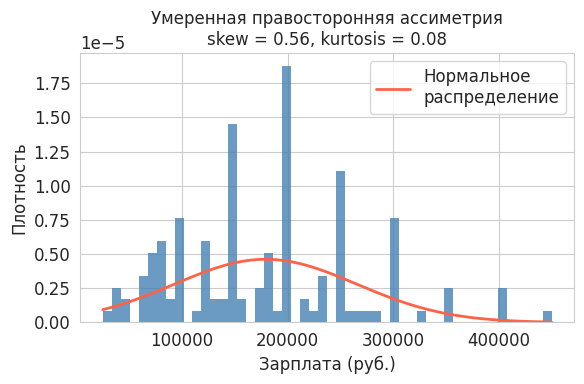

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Данные
minSalary_distr = df[df['Мин. зарплата (рублей)'].notna()]['Мин. зарплата (рублей)']

# Расчёт skewness и kurtosis
skew = stats.skew(minSalary_distr)
kurt = stats.kurtosis(minSalary_distr)

fig, ax = plt.subplots(figsize=(6, 4))

# Гистограмма с плотностью
ax.hist(minSalary_distr, bins=50, color='steelblue', alpha=0.8, edgecolor='none', density=True)

# Кривая нормального распределения для сравнения
x_norm = np.linspace(minSalary_distr.min(), minSalary_distr.max(), 200)
ax.plot(x_norm, stats.norm.pdf(x_norm, minSalary_distr.mean(), minSalary_distr.std()),
        color='tomato', linewidth=2, label='Нормальное\nраспределение')

# Оформление
ax.set_title(f'Умеренная правосторонняя ассиметрия\nskew = {skew:.2f}, kurtosis = {kurt:.2f}', fontsize=12)
ax.set_xlabel('Зарплата (руб.)')
ax.set_ylabel('Плотность')
ax.legend()

plt.tight_layout()
plt.show()

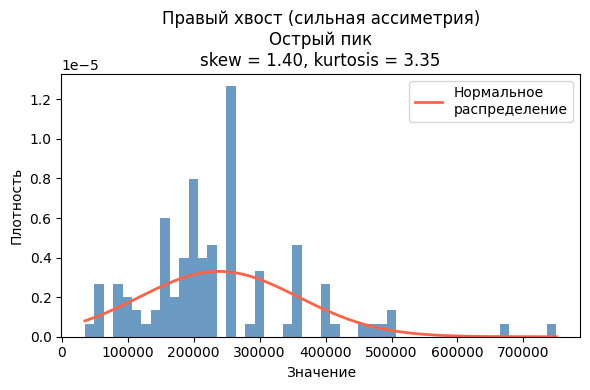

In [18]:
maxSalary_distr = df[df['Макс. зарплата (рублей)'].notna()]['Макс. зарплата (рублей)']
np.random.seed(42)
n = 2000

#Расчёт skewness и kurtosis
skew = stats.skew(maxSalary_distr)
kurt = stats.kurtosis(maxSalary_distr)

fig, ax = plt.subplots(figsize=(6, 4))

# Гистограмма
ax.hist(maxSalary_distr, bins=50, color='steelblue', alpha=0.8, edgecolor='none', density=True)

# Кривая нормального распределения для сравнения
x_norm = np.linspace(maxSalary_distr.min(), maxSalary_distr.max(), 200)
ax.plot(x_norm, stats.norm.pdf(x_norm, maxSalary_distr.mean(), maxSalary_distr.std()),
        color='tomato', linewidth=2, label='Нормальное\nраспределение')

# Оформление
ax.set_title(f'Правый хвост (сильная ассиметрия)\nОстрый пик\nskew = {skew:.2f}, kurtosis = {kurt:.2f}', fontsize=12)
ax.set_xlabel('Значение')
ax.set_ylabel('Плотность')
ax.legend()

plt.tight_layout()
plt.show()

Q1=120000.0, Q3=250000.0, IQR=130000.0
Допустимый диапазон: [-75000.0, 445000.0]
Выбросов: 4, значения: [4.50000000e+005 1.50015002e+299 7.00070007e+299 5.00050005e+299]


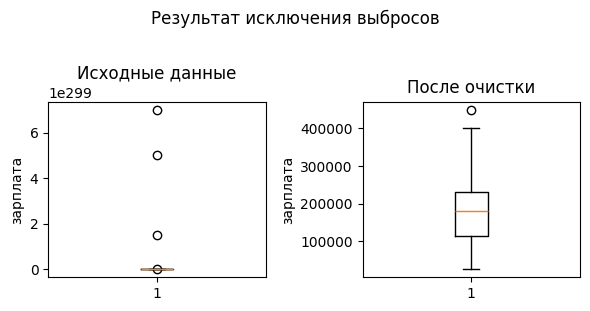

In [19]:
#РАБОТА С ВЫБРОСАМИ МЕТОДОМ КВАРТИЛЕЙ - МИН. ЗАРПЛАТА
#признак "Мин. зарплата"
Q1 = minSalary_distr.quantile(0.25)
Q3 = minSalary_distr.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f'Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}')
print(f'Допустимый диапазон: [{lower:.1f}, {upper:.1f}]')

outliers = minSalary_distr[(minSalary_distr < lower) | (minSalary_distr > upper)]
print(f'Выбросов: {len(outliers)}, значения: {outliers.values}')
#450 000 явно не является аномальным значением, такое значение зарплаты вполне приемлемо.
#исключим все значения, помеченные как выбросы помимо значения 450 000
df.loc[df['Мин. зарплата (рублей)'] > 450000, 'Мин. зарплата (рублей)'] = np.nan
minSalary_cleaned = minSalary_distr[minSalary_distr <= 450000]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].boxplot(minSalary_distr)
axes[0].set_title('Исходные данные')

axes[1].boxplot(minSalary_cleaned)
axes[1].set_title('После очистки')

for ax in axes:
    ax.set_ylabel('зарплата')

plt.suptitle('Результат исключения выбросов', y=1.02)
plt.tight_layout()
plt.show()

Q1=170000.0, Q3=262500.0, IQR=92500.0
Допустимый диапазон: [31250.0, 401250.0]
Выбросов: 8, значения: [450000. 420000. 675000. 500000. 750000. 500000. 487500. 470000.]


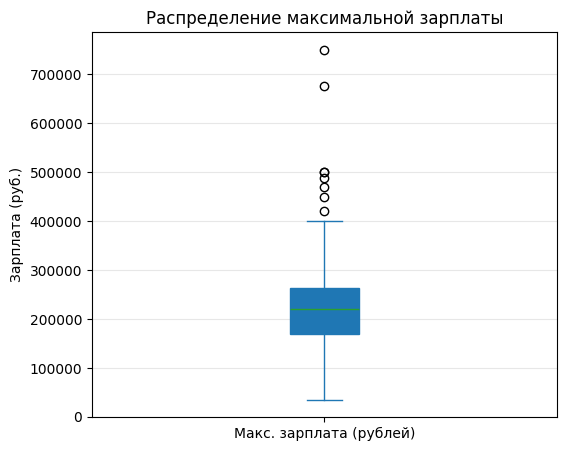

In [20]:
#РАБОТА С ВЫБРОСАМИ МЕТОДОМ КВАРТИЛЕЙ - МАКС. ЗАРПЛАТА
#признак "Макс. зарплата"
Q1 = maxSalary_distr.quantile(0.25)
Q3 = maxSalary_distr.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(f'Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}')
print(f'Допустимый диапазон: [{lower:.1f}, {upper:.1f}]')

outliers = maxSalary_distr[(maxSalary_distr < lower) | (maxSalary_distr > upper)]
print(f'Выбросов: {len(outliers)}, значения: {outliers.values}')

#НИ ОДНО ИЗ ВЫЯВЛЕННЫХ ЗНАЧЕНИЙ НЕ ЯВЛЯЕТСЯ ЛОЖНЫМ ДАННЫМ

maxSalary_distr.plot.box(
    figsize=(6, 5),       # размер графика
    vert=True,            # вертикальная ориентация
    patch_artist=True     # закрасить ящик
)

plt.title('Распределение максимальной зарплаты')
plt.ylabel('Зарплата (руб.)')
plt.grid(axis='y', alpha=0.3)
plt.show()

,Мин. зарплата,Макс. зарплата
count,138,105
mean,179220,238286
std,86340,120785
min,25000,35000
25%,112500,170000
50%,179500,220000
75%,230000,262500
max,450000,750000


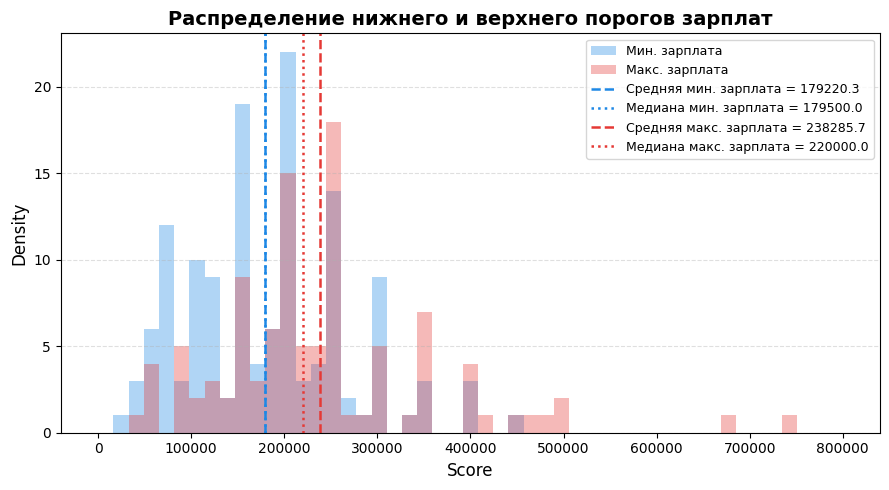

In [21]:
#ИТОГОВЫЙ НАБОР ДАННЫХ И ЕГО ХАРАКТЕРИСТИКИ
noted_minSalary = df[df['Мин. зарплата (рублей)'].notna()]['Мин. зарплата (рублей)']
noted_maxSalary = df[df['Макс. зарплата (рублей)'].notna()]['Макс. зарплата (рублей)']
stats = pd.DataFrame({
    'Мин. зарплата': noted_minSalary.describe().apply(lambda x: f'{x:.0f}'),
    'Макс. зарплата': noted_maxSalary.describe().apply(lambda x: f'{x:.0f}')
    })
display(stats)

plt.figure(figsize=(9, 5))
bins = np.linspace(0, 800000, 50)

plt.hist(noted_minSalary, bins, alpha=0.35, color='#1E88E5', label='Мин. зарплата')
plt.hist(noted_maxSalary, bins, alpha=0.35, color='#E53935', label='Макс. зарплата')

m1 = noted_minSalary.mean()
med1 = np.median(noted_minSalary)
m2 = noted_maxSalary.mean()
med2 = np.median(noted_maxSalary)

# Вертикальные линии: -- для mean, : для median
plt.axvline(m1,   color='#1E88E5', ls='--', lw=1.8, label=f'Средняя мин. зарплата = {m1:.1f}')
plt.axvline(med1, color='#1E88E5', ls=':',  lw=1.8, label=f'Медиана мин. зарплата = {med1:.1f}')
plt.axvline(m2,   color='#E53935', ls='--', lw=1.8, label=f'Средняя макс. зарплата = {m2:.1f}')
plt.axvline(med2, color='#E53935', ls=':',  lw=1.8, label=f'Медиана макс. зарплата = {med2:.1f}')

plt.title('Распределение нижнего и верхнего порогов зарплат', fontsize=14, fontweight='bold')
plt.xlabel('Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(loc='upper right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [22]:
display(df)

,Тип вакансии,Название вакансии,Мин. зарплата (рублей),Макс. зарплата (рублей),Тип зарплаты,Требуемый опыт (лет),Город,Компания,Требуемые навыки,Дата публикации
0,ML-инженер,ML-инженер (Middle),NaN,NaN,NaN,NaN,Нижний Новгород,Riverstart (ООО Риверстарт),"Docker, MLOps, Kubernetes, Deep Learning, Apac...",2026-09-06
1,ML-инженер,Senior ML Engineer (ИИ-агенты),NaN,NaN,NaN,3.0,Москва,Сбер. Data Science,Не указаны,2026-09-06
2,ML-инженер,Lead ML Engineer,200000.0,300000.0,gross,NaN,Москва,АО ТМГТ,Не указаны,2026-09-06
3,ML-инженер,ML-инженер по автоматизации планирования произ...,277500.0,NaN,gross,NaN,Елабужский район,Алабуга. Аппарат генерального директора,Не указаны,2026-09-06
5,ML-инженер,ML-инженер,NaN,NaN,NaN,3.0,Казань,Т-Банк. ИТ. Разработка,"Big Data, Python, PyTorch",2026-08-06
...,...,...,...,...,...,...,...,...,...,...
596,DevOps инженер,Стажер Product-инженер (DevOps),NaN,NaN,NaN,NaN,Москва,Крупный технологичный банк,"Docker, Git, Kubernetes, Linux, Bash",NaT
597,DevOps инженер,Администратор 1С/DevOps/Инженер 1С,NaN,NaN,NaN,3.0,Москва,ПАО Ростелеком,Не указаны,NaT
598,DevOps инженер,Senior DevOps Engineer,NaN,NaN,NaN,3.0,Москва,АИМОР,Не указаны,2026-11-05
599,DevOps инженер,Руководитель группы devops-инженеров,NaN,NaN,NaN,NaN,Санкт-Петербург,Okko,"Terraform/IaC, Kubernetes, Groovy, Python, CI/...",NaT


[[172, 'SQL'],
 [100, 'API технологии'],
 [93, 'Git'],
 [92, 'Python'],
 [85, 'Docker'],
 [75, 'Linux'],
 [66, 'JavaScript'],
 [65, 'Бизнес-анализ'],
 [60, 'Kubernetes'],
 [57, 'Моделирование процессов'],
 [46, 'React'],
 [44, 'CI/CD'],
 [42, 'TypeScript'],
 [39, 'DevOps'],
 [38, 'Управленческие навыки']]

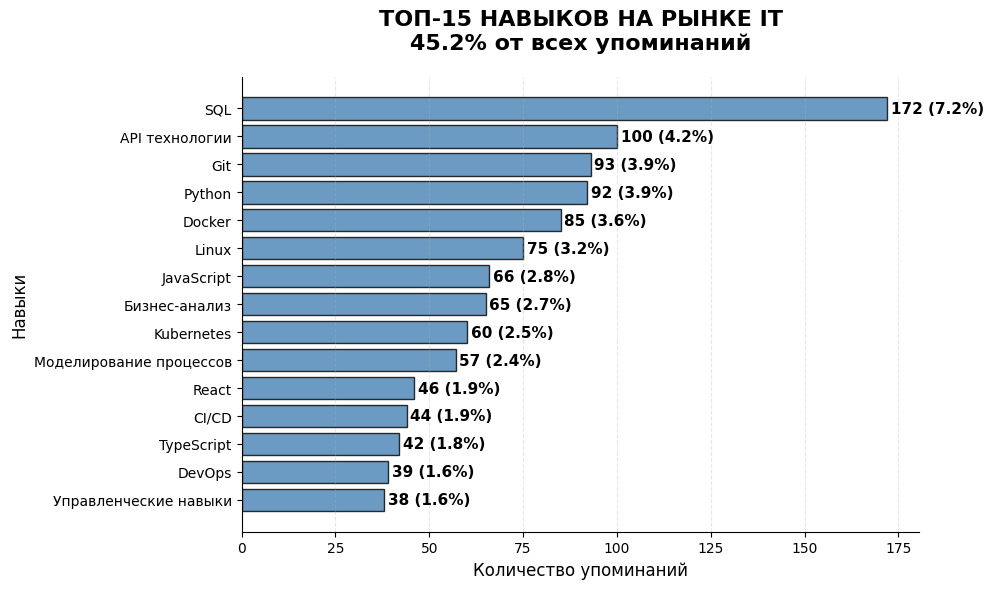


СТАТИСТИКА ПО ТОП-15 НАВЫКОВ
Всего упоминаний всех навыков: 2375
Топ-15 занимают: 1074 (45.2%) от всех упоминаний


In [23]:
#АНАЛИЗ ТРЕБУЕМЫХ НАВЫКОВ НА РЫНКЕ - ВОСТРЕБОВАННОСТЬ НАВЫКОВ
all_normalized = set(all_normalized) #СПИСОК ВСЕХ НАВЫКОВ
count_skills = [[0, skill] for skill in all_normalized]

all_noted = 0
for skills_str in df['Требуемые навыки']:
  if skills_str != "Не указаны":
    skills_arr = skills_str.split(', ')
    for skill in skills_arr:
      for skill_count in count_skills:
        if skill_count[1] == skill:
          skill_count[0] += 1
      all_noted += 1

#ТОП 15 самых востребованных навыков на рынке
top15_skills = sorted(count_skills, reverse = True)[:15]
display(top15_skills)
skills, count, perc  = [],  [], []
for item in top15_skills:
  skills.append(item[1])
  count.append(item[0])
  perc.append(item[0]/all_noted * 100)

fig, ax = plt.subplots(figsize=(10, 6))

# Горизонтальный бар-чарт
bars = ax.barh(skills, count, color='steelblue', edgecolor='black', alpha=0.8)

# Добавляем подписи количества и процента
for i, (bar, counts, pct) in enumerate(zip(bars, count, perc)):
    # Подпись справа от столбца
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{counts} ({pct:.1f}%)',
            va='center', ha='left', fontsize=11, fontweight='bold')

# Оформление
ax.set_xlabel('Количество упоминаний', fontsize=12)
ax.set_ylabel('Навыки', fontsize=12)
ax.set_title(f'ТОП-15 НАВЫКОВ НА РЫНКЕ IT\n{sum(count)/all_noted*100:.1f}% от всех упоминаний',
             fontsize=16, fontweight='bold', pad=20)

# Инвертируем ось Y (чтобы первый был сверху)
ax.invert_yaxis()

# Добавляем сетку
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Убираем верхнюю и правую границы
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Настройка внешнего вида
plt.tight_layout()

# Показываем график
plt.show()

# Вывод статистики в консоль
print("\nСТАТИСТИКА ПО ТОП-15 НАВЫКОВ")
print(f"Всего упоминаний всех навыков: {all_noted}")
print(f"Топ-15 занимают: {sum(count)} ({sum(count)/all_noted*100:.1f}%) от всех упоминаний")

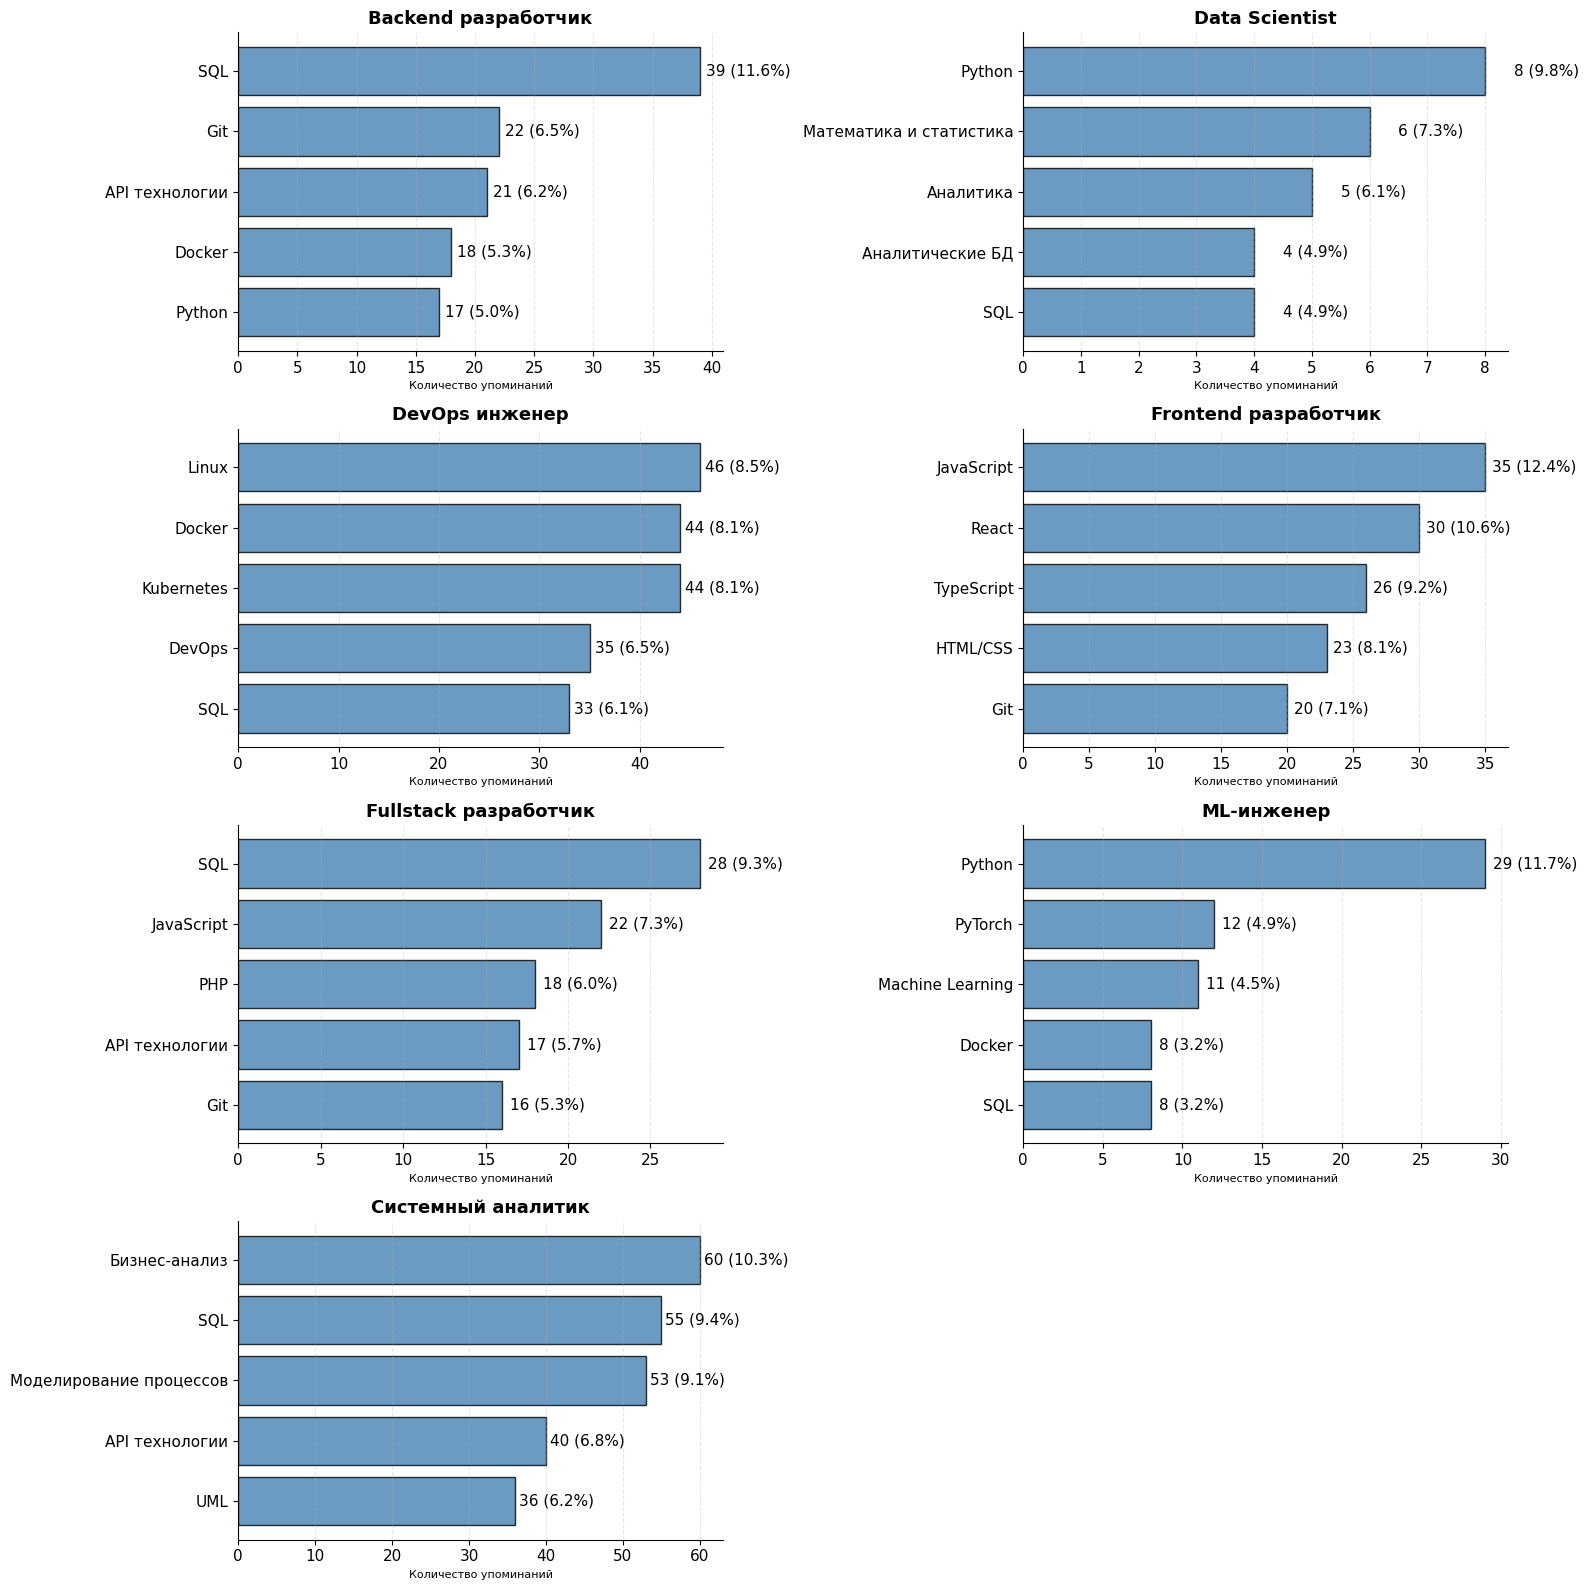

In [24]:
from collections import Counter
#АНАЛИЗ ВОСТРЕБОВАННОСТИ НАВЫКОВ В ЗАВИИСИМОСТИ ОТ РОЛЕЙ
grouped_skills = df.groupby('Тип вакансии')['Требуемые навыки'].apply(
    lambda x: [skill for skills_str in x if skills_str != "Не указаны"
               for skill in skills_str.split(", ")]
)

role_skills_top5 = {}

all_count = []
for role, skills_list in grouped_skills.items():
    if skills_list:
        counter = Counter(skills_list)
        all_count.append(len(skills_list))
        top5 = [(skill, count) for skill, count in counter.most_common(5)]
        role_skills_top5[role] = top5[::-1]
    else:
        role_skills_top5[role] = []

top5_df = pd.DataFrame(role_skills_top5)

#ВИЗУАЛИЗАЦИЯ
roles_to_plot = list(role_skills_top5.keys())

#(3 строки, 4 столбца)
n_cols = 2
n_rows = (len(roles_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()  # делаем плоским для удобного перебора

for idx, role in enumerate(roles_to_plot):
    ax = axes[idx]

    # Извлекаем навыки и их количество
    top5 = role_skills_top5[role]
    skills = [item[0] for item in top5]
    counts = [item[1] for item in top5]

    # Горизонтальный барчарт
    bars = ax.barh(skills, counts, color='steelblue', edgecolor='black', alpha=0.8)

    # Добавляем значения в конце строк
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{count} ({round(count/all_count[idx] *100, 1)}%)", va='center',
                ha='left', fontsize=11)

    # Оформление
    ax.set_title(role, fontsize=13, fontweight='bold')
    ax.set_xlabel('Количество упоминаний', fontsize=8)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Скрываем лишние пустые подграфики
for idx in range(len(roles_to_plot), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [25]:
from itertools import combinations
from collections import Counter

# Собираем комбинации навыков
skill_pairs = Counter()

skill_alone = Counter()

for skills_str in df['Требуемые навыки']:
    if skills_str != "Не указаны":
        skills_list = skills_str.split(", ")
        unique_skills = set(skills_list)

        # Подсчёт одиночных навыков
        for skill in skills_list:
            skill_alone[skill] += 1

        # Подсчёт пар навыков (только уникальные комбинации)
        if len(unique_skills) >= 2:
            for pair in combinations(unique_skills, 2):
                skill_pairs[tuple(sorted(pair))] += 1

#ВИЗУАЛИЗАЦИЯ ТОП-10 ПАР
print("ТОП-10 ПАР НАВЫКОВ")
top_pairs = skill_pairs.most_common(10)
for pair, count in top_pairs:
    print(f"  {pair[0]} + {pair[1]}: {count} раз")

# Собираем уникальные навыки из топ-пар
skills_in_top_pairs = set()
for pair, _ in top_pairs:
    skills_in_top_pairs.add(pair[0])
    skills_in_top_pairs.add(pair[1])

ТОП-10 ПАР НАВЫКОВ
  API технологии + SQL: 65 раз
  Docker + SQL: 52 раз
  Git + SQL: 51 раз
  Docker + Linux: 43 раз
  Python + SQL: 42 раз
  Linux + SQL: 40 раз
  Docker + Kubernetes: 37 раз
  Бизнес-анализ + Моделирование процессов: 37 раз
  Docker + Git: 36 раз
  UML + Моделирование процессов: 35 раз


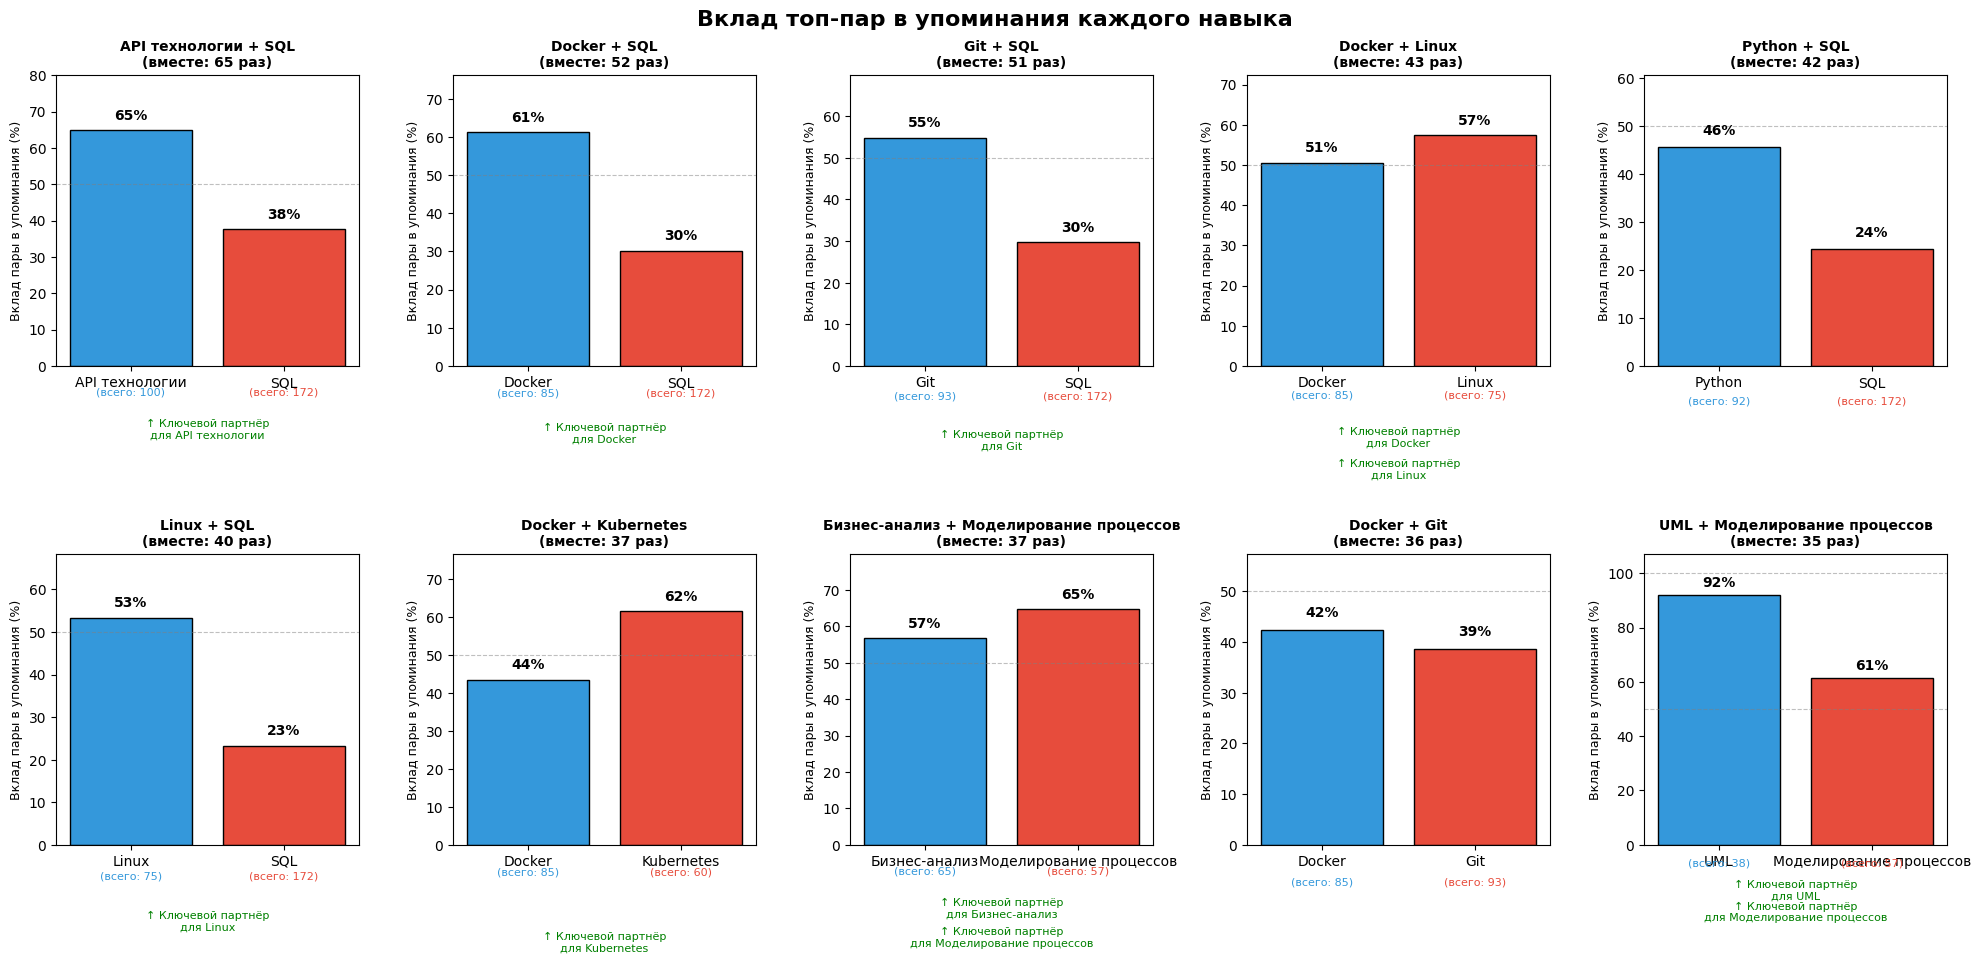

In [26]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('Вклад топ-пар в упоминания каждого навыка', fontsize=16, fontweight='bold')

for idx, ((skill1, skill2), pair_count) in enumerate(top_pairs):
    ax = axes[idx // 5][idx % 5]

    alone1 = skill_alone[skill1]
    alone2 = skill_alone[skill2]

    # Процент упоминаний, приходящихся на эту пару
    pct1 = (pair_count / alone1 * 100) if alone1 > 0 else 0
    pct2 = (pair_count / alone2 * 100) if alone2 > 0 else 0

    # Строим столбцы
    bars = ax.bar([skill1, skill2], [pct1, pct2],
                  color=['#3498DB', '#E74C3C'], edgecolor='black', linewidth=1)

    # Добавляем подписи на столбцах
    for bar, pct in zip(bars, [pct1, pct2]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{pct:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Добавляем количество упоминаний под названием
    ax.text(0, -8, f'(всего: {alone1})', ha='center', fontsize=8, color='#3498DB', transform=ax.transData)
    ax.text(1, -8, f'(всего: {alone2})', ha='center', fontsize=8, color='#E74C3C', transform=ax.transData)

    # Заголовок с количеством пар
    ax.set_title(f'{skill1} + {skill2}\n(вместе: {pair_count} раз)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Вклад пары в упоминания (%)', fontsize=9)
    ax.set_ylim(0, max(max(pct1, pct2) + 15, 30))
    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

    # Добавляем пояснение внизу
    if pct1 > 50:
        ax.text(0.5, -20, f'↑ Ключевой партнёр\nдля {skill1}', ha='center', fontsize=8, color='green')
    if pct2 > 50:
        ax.text(0.5, -28, f'↑ Ключевой партнёр\nдля {skill2}', ha='center', fontsize=8, color='green')

plt.tight_layout()
plt.show()


In [27]:
#ЗАВИСИМОСТЬ ТРЕБУЕМЫХ НАВЫКОВ И ТРЕБУЕМОГО ОПЫТА РАБОТЫ
#ЗДЕСЬ ОЦЕНИМ КАКИЕ НАВЫКИ ТРЕБУЮТСЯ ДЛЯ ВХОДА В СПЕЦИАЛЬНОСТЬ, А КАКИЕ МОГУТ БЫТЬ ПРИОБРЕТЕНЫ ПОЗЖЕ
grouped = df.groupby(['Тип вакансии', 'Требуемый опыт (лет)'])['Требуемые навыки'].apply(
    lambda x: [skill for skills_str in x if skills_str != "Не указаны"
               for skill in skills_str.split(", ")]
)


most_common = {}
for role in roles:
  most_common[role] = {}
  for exp in [-1, 3]:
    key = (role, exp)
    skills_list = grouped.get(key, [])

    skills_count = Counter(skills_list)
    most_common[role][exp] = skills_count.most_common(10)

diffs = {}

for role in roles:
  diffs[role] = {
      'Нет опыта': [],
      'Есть опыт': [],
      'Общее': []
  }
  for skill in most_common[role][-1]:
    if skill[0] not in [s[0] for s in most_common[role][3]]:
      diffs[role]['Нет опыта'].append(skill)
    else:
      diffs[role]['Общее'].append(skill)
  for skill in most_common[role][3]:
    if skill[0] not in [s[0] for s in most_common[role][-1]]:
      diffs[role]['Есть опыт'].append(skill)

# Создаём таблицу для визуализации
vis_data = []
for role, data in diffs.items():
    vis_data.append({
        'Роль': role,
        'Опыт не указан': ', '.join([s[0] for s in data['Нет опыта'][:3]]),
        'Только с опытом': ', '.join([s[0] for s in data['Есть опыт'][:3]]),
        'Общие': ', '.join([s[0] for s in data['Общее'][:3]])
    })

df_viz = pd.DataFrame(vis_data)
display(df_viz)

#ОБЩИЕ НАВЫКИ - БАЗА ДЛЯ СПЕЦИАЛИСТОВ ЛЮБОГО УРОВНЯ
#ОДНАКО В ВАКАНСИЯХ С НЕУКАЗАННЫМ ОПЫТОМ ТРЕБОВАНИЯ НЕ ВСЕГДА НИЖЕ, ЧЕМ В ВАКАНСИЯХ С УКАЗАННЫМ ОПЫТОМ
#ВЫВОД: ПРИ ВЫБОРЕ ПОДХОДЯЩЕЙ ВАКАНСИИ СЛЕДУЕТ СМОТЕРТЬ В ПЕРВУЮ ОЧЕРЕДЬ НА ТРЕБУЕМЫЕ НАВЫКИ
#ОПЫТ РАБОТЫ МОЖЕТ ТРЕБОВАТЬСЯ ДАЖЕ ЕСЛИ ЭТО НЕ УКАЗАНО ЯВНО


,Роль,Опыт не указан,Только с опытом,Общие
0,ML-инженер,,"Python, Machine Learning, LLM/GenAI",
1,Data Scientist,,"Python, Математика и статистика, Аналитические БД",
2,Frontend разработчик,,"JavaScript, React, TypeScript",
3,Backend разработчик,,"SQL, Git, Python",
4,Fullstack разработчик,,"SQL, JavaScript, PHP",
5,Системный аналитик,,"Бизнес-анализ, SQL, Моделирование процессов",
6,DevOps инженер,,"Linux, Kubernetes, Docker",


Доступные колонки: ['Тип вакансии', 'Название вакансии', 'Мин. зарплата (рублей)', 'Макс. зарплата (рублей)', 'Тип зарплаты', 'Требуемый опыт (лет)', 'Город', 'Компания', 'Требуемые навыки', 'Дата публикации']


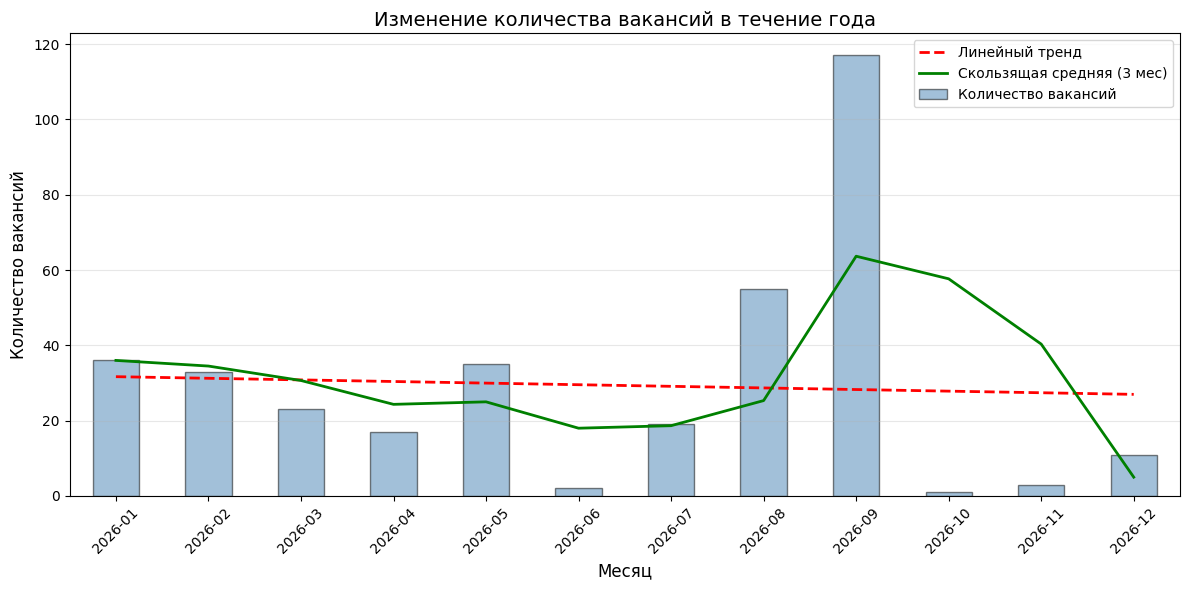

Тренд: падение на 0.4 вакансий в месяц


In [29]:
# ГРУППИРУЕМ И СЧИТАЕМ КОЛ-ВО

# Проверяем, какие колонки есть в df
print("Доступные колонки:", df.columns.tolist())

# Если есть колонка с датой, например 'Дата публикации'
if 'Дата публикации' in df.columns:
    # Преобразуем в datetime если еще не преобразовали
    df['Дата публикации'] = pd.to_datetime(df['Дата публикации'], dayfirst=True, errors='coerce')

    # Создаем колонку с месяцем
    df['Месяц'] = df['Дата публикации'].dt.strftime('%Y-%m')  # или '%B' для названия месяца

    # Группируем и считаем количество
    monthly_counts = df.groupby('Месяц').size()

    # Сортируем по месяцам
    monthly_counts = monthly_counts.sort_index()

    # ГРАФИК С ТРЕНДОМ И СКОЛЬЗЯЩЕЙ СРЕДНЕЙ
    plt.figure(figsize=(12, 6))

    # Барчарт
    monthly_counts.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.5, label='Количество вакансий')

    # Линия тренда
    x = np.arange(len(monthly_counts))
    y = monthly_counts.values
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), color='red', linewidth=2, linestyle='--', label=f'Линейный тренд')

    # Скользящая средняя (3 месяца)
    rolling_mean = monthly_counts.rolling(window=3, min_periods=1).mean()
    plt.plot(x, rolling_mean.values, color='green', linewidth=2, label='Скользящая средняя (3 мес)')

    plt.title('Изменение количества вакансий в течение года', fontsize=14)
    plt.xlabel('Месяц', fontsize=12)
    plt.ylabel('Количество вакансий', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Тренд: {'рост' if z[0] > 0 else 'падение'} на {abs(z[0]):.1f} вакансий в месяц")

else:
    print("Колонка 'Дата публикации' не найдена. Проверьте названия колонок:")
    print(df.columns.tolist())

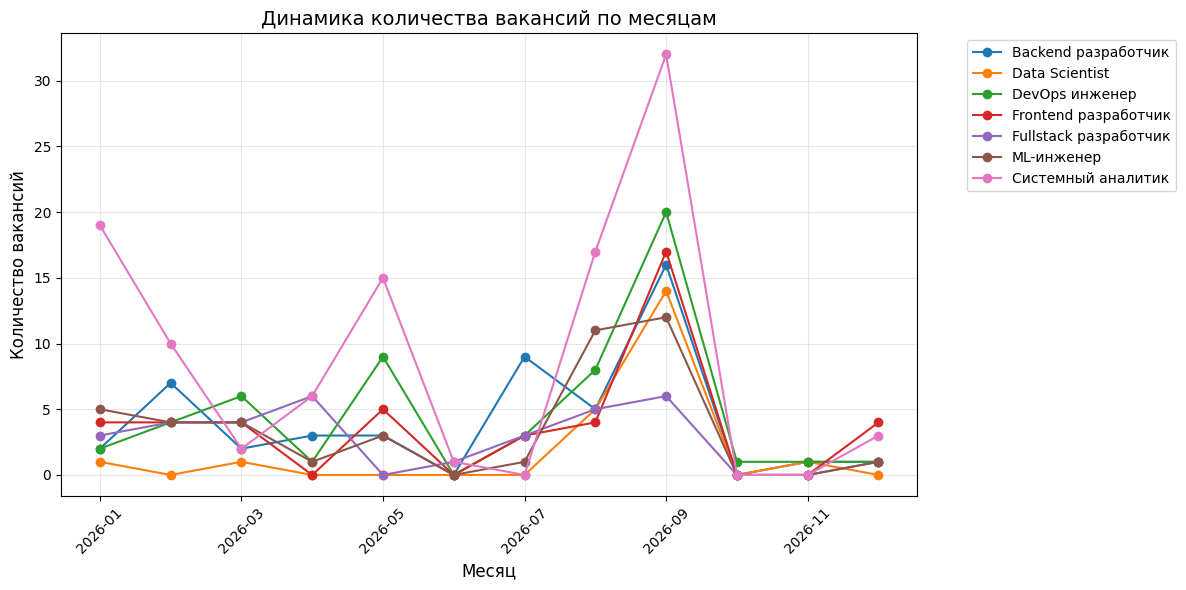

In [30]:
df['Месяц'] = df['Дата публикации'].dt.strftime('%Y-%m')

# ГРУППИРУЕМ И СЧИТАЕМ КОЛ-ВО
grouped = df.groupby(['Тип вакансии', 'Месяц']).size().reset_index(name='Количество')

# Сводная таблица
pivot = grouped.pivot(index='Тип вакансии', columns='Месяц', values='Количество').fillna(0)

#ГРАФИК
import matplotlib.pyplot as plt

pivot.T.plot(figsize=(12, 6), marker='o')
plt.title('Динамика количества вакансий по месяцам', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество вакансий', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [31]:
# Для каждой роли считаем тренд
roles_trend = {}

for role in df['Тип вакансии'].unique():
    role_monthly = df[df['Тип вакансии'] == role].groupby(
        pd.to_datetime(df['Дата публикации']).dt.to_period('M')).size()
    if len(role_monthly) > 3:
        # Линейный тренд
        x = np.arange(len(role_monthly))
        z = np.polyfit(x, role_monthly.values, 1)
        roles_trend[role] = z[0]  # наклон

# Сортировка по росту
sorted_roles = sorted(roles_trend.items(), key=lambda x: x[1], reverse=True)

print("ТЕМПЫ РОСТА ПО РОЛЯМ")
for role, growth in sorted_roles:
    print(f"{role}: {growth:.2f} вакансий в месяц")

#БЫСТРЕЕ ВСЕГО ЗА ПОСЛЕДНИЙ ГОД УВЕЛИЧИВАЛОСЬ КОЛ-ВО ВАКАНСИЙ ДЛЯ РАБОТЫ С ДАННЫМИ
#ЭТО МОЖНО ОБЪЯСНИТЬ БЫСТРЫМ ТЕМПОМ РОСТА КОЛИЧЕСТВА ДАННЫХ В ИНТЕРНЕТЕ
#FULLSTACK РАЗРАБОТЧИКИ СТАНОВЯТСЯ МЕНЕЕ ВОСТРЕБОВАНЫ, ТАК КАК ОСУЩЕСТВЛЯЕТСЯ ПЕРЕХОД К
#СПЕЦИАЛИСТАМ БОЛЕЕ УЗКОЙ СПЕЦИАЛИЗАЦИИ, ДЛЯ КАЖДОГО ИЗ НИХ СТАНОВИТСЯ БОЛЬШЕ ЗАДАЧ,
#КОЛИЧЕСТВО ВАКАНСИЙ ДЛЯ DEVOPS ИНЖЕНЕРОВ ПРАКТИЧЕСКИ НЕ МЕНЯЕТСЯ, ЧТО МОЖЕТ ОЗНАЧАТЬ ТО,
#ЧТО РЫНОК НАСЫЩЕН, НОВЫЕ СПЕЦИАЛИСТЫ НЕ ТРЕБУЮТСЯ
#ОСТАЛЬНЫЕ ВАКАНСИИ ПОКАЗЫВАЮТ УМЕРЕННЫЙ СТАБИЛЬНЫЙ РОСТ

ТЕМПЫ РОСТА ПО РОЛЯМ
Data Scientist: 1.30 вакансий в месяц
Frontend разработчик: 0.75 вакансий в месяц
Системный аналитик: 0.45 вакансий в месяц
ML-инженер: 0.37 вакансий в месяц
Backend разработчик: 0.19 вакансий в месяц
DevOps инженер: 0.05 вакансий в месяц
Fullstack разработчик: -0.05 вакансий в месяц


In [32]:
#ОСНОВНЫЕ МЕТРИКИ
print("ОБЩАЯ ДИНАМИКА РЫНКА")
print(f"Всего вакансий за период: {monthly_counts.sum()}")
print(f"Среднее в месяц: {monthly_counts.mean():.1f}")
print(f"Максимум: {monthly_counts.max()} ({monthly_counts.idxmax()})")
print(f"Минимум: {monthly_counts.min()} ({monthly_counts.idxmin()})")
print(f"Стандартное отклонение: {monthly_counts.std():.1f}")

ОБЩАЯ ДИНАМИКА РЫНКА
Всего вакансий за период: 352
Среднее в месяц: 29.3
Максимум: 117 (2026-09)
Минимум: 1 (2026-10)
Стандартное отклонение: 32.1


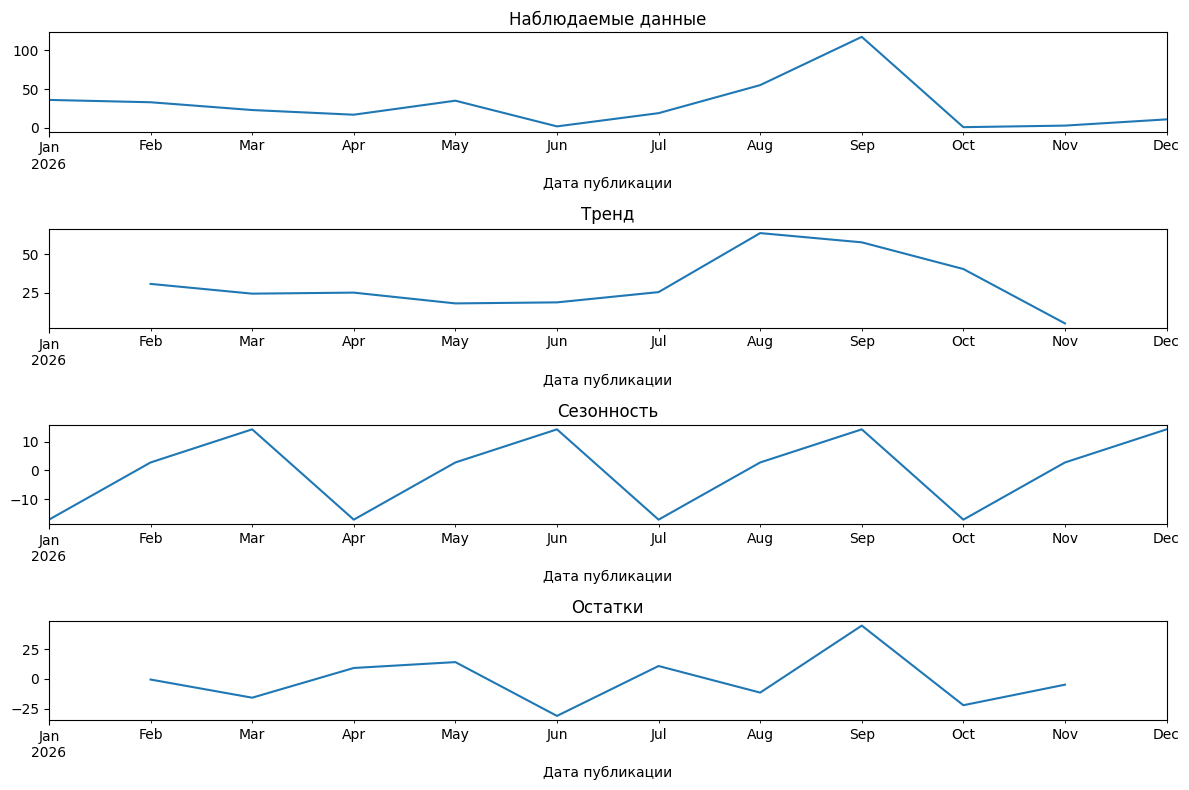

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Агрегируем по месяцам
monthly = df.groupby(pd.to_datetime(df['Дата публикации']).dt.to_period('M')).size()
monthly.index = monthly.index.to_timestamp()

# Декомпозиция
decomp = seasonal_decompose(monthly, model='additive', period=3)


fig, axes = plt.subplots(4, 1, figsize=(12, 8))
decomp.observed.plot(ax=axes[0], title='Наблюдаемые данные')
decomp.trend.plot(ax=axes[1], title='Тренд')
decomp.seasonal.plot(ax=axes[2], title='Сезонность')
decomp.resid.plot(ax=axes[3], title='Остатки')
plt.tight_layout()
plt.show()

#ВВИДУ ОГРАНИЧЕННОГО КОЛ-ВА ДАННЫХ НЕЛЬЗЯ ПРИНИМАТЬ ВРЕМЕННОЙ АНАЛИЗ КАК ИСТИНУ
#АНАЛИЗ ОСНОВАН ЛИШЬ НА ДАННЫХ ЗА ПОСЛЕДНИЙ ГОД

#В ДАННЫХ ВИДЕН СИЛЬНЫЙ РОСТ КОЛИЧЕСТВА ВАКАНСИЙ К СЕНТЯБРЮ, ЧТО ОБЪЯСНЯЕТСЯ ТЕМ, ЧТО
#СЕНТЯБРЬ - МЕСЯЦ ПИКА ДЕЛОВОЙ АКТИВНОСТИ, ЛЮДИ ВЫХОДЯТ С ОТПУСКОВ
#СЕНТЯБРЬ - ХОРОШЕЕ ВРЕМЯ ДЛЯ ПОИСКА РАБОТЫ ПО ЛЮБОЙ ИЗ СПЕЦИАЛЬНОСТЕЙ

#СЕЗОННОСТЬ БЫЛА ПРОАНАЛИЗИРОВАНА С ПЕРИОДОМ В 3 МЕСЯЦА, ЕСЛИ БЫ ЦИКЛ ПОВТОРЯЛСЯ КАЖДЫЕ 3 МЕСЯЦА
#ОДНАКО ПО ОСТАТКАМ ВИДНО, ЧТО В МАРТЕ, ИЮНЕ И ОКТЯБРЕ КОЛ-ВО ВАКАНСИЙ ГОРАЗДО НИЖЕ ОЖИДАЕМОГО КОЛИЧЕСТВА
#В ТО ВРЕМЯ КАК В СЕНТЯБРЕ - НАМНОГО БОЛЬШЕ
#Это указывает на то, что 3 месячный цикл (по сезонам) не является доминирующим паттерном для рынка IT вакансий

In [35]:
# Настройка стиля - делаем графики чистыми и читаемыми
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


In [36]:
#ЗАГРУЗКА И ОЧИСТКА ДАННЫХ
df_clean = df.copy()

# Исправление несогласованных названий городов (дублирует cell 9, но для df_clean)
df_clean['Город'] = df_clean['Город'].replace({
    'город Новосибирск': 'Новосибирск',
    'городской округ Химки': 'Химки',
    'Киров (Кировская область)': 'Киров'
})

# Очистка зарплат
df_clean['Мин. зарплата (рублей)'] = df_clean['Мин. зарплата (рублей)'].astype(str).str.replace(',', '.').str.replace(' ', '')
df_clean['Макс. зарплата (рублей)'] = df_clean['Макс. зарплата (рублей)'].astype(str).str.replace(',', '.').str.replace(' ', '')

df_clean['Мин. зарплата (рублей)'] = pd.to_numeric(df_clean['Мин. зарплата (рублей)'], errors='coerce')
df_clean['Макс. зарплата (рублей)'] = pd.to_numeric(df_clean['Макс. зарплата (рублей)'], errors='coerce')

# Средняя зарплата (только по указанным значениям)
df_clean['salary_mean'] = df_clean[['Мин. зарплата (рублей)', 'Макс. зарплата (рублей)']].mean(axis=1)
df_clean['salary_mean'] = df_clean['salary_mean'].fillna(df_clean['Мин. зарплата (рублей)'])
df_clean['salary_mean'] = df_clean['salary_mean'].fillna(df_clean['Макс. зарплата (рублей)'])

# Признак: зарплата указана явно (1) или скрыта намеренно (0)
df_clean['salary_is_visible'] = df_clean['salary_mean'].notna().astype(int)

# salary_mean_filled: для корреляции и регрессии — пропуски заменяем 0
df_clean['salary_mean_filled'] = df_clean['salary_mean'].fillna(0)


# Фильтруем выбросы только по вакансиям с указанной зарплатой (для визуализации)
q95 = df_clean[df_clean['salary_is_visible'] == 1]['salary_mean'].quantile(0.95)
# df_filtered включает ВСЕ вакансии (в т.ч. без зарплаты)
df_filtered = df_clean[df_clean['salary_mean'].isna() | (df_clean['salary_mean'] <= q95)].copy()

print(f"Всего вакансий: {len(df_clean)}")
print(f"Вакансий с указанной зарплатой: {df_clean['salary_is_visible'].sum()}")
print(f"Вакансий без зарплаты (salary_is_visible=0): {(df_clean['salary_is_visible']==0).sum()}")
print(f"После фильтрации выбросов (все вакансии): {len(df_filtered)}")


Всего вакансий: 598
Вакансий с указанной зарплатой: 175
Вакансий без зарплаты (salary_is_visible=0): 423
После фильтрации выбросов (все вакансии): 590


In [39]:
#ПОДГОТОВКА ПРИЗНАКОВ
from sklearn.preprocessing import LabelEncoder

#Опыт работы (заполняем пропуски нулем)
df_filtered['Требуемый опыт (лет)'] = df_filtered['Требуемый опыт (лет)'].fillna(0)

# Грейд из названия
def extract_grade(title):
    title = str(title).lower()
    if 'junior' in title or 'джун' in title or 'стажер' in title or 'стажёр' in title:
        return 'Junior'
    elif 'middle' in title or 'мидл' in title:
        return 'Middle'
    elif 'senior' in title or 'старш' in title or 'ведущ' in title:
        return 'Senior'
    elif 'lead' in title or 'тимлид' in title or 'руковод' in title or 'head' in title:
        return 'Lead'
    else:
        return 'Not specified'

df_filtered['grade'] = df_filtered['Название вакансии'].apply(extract_grade)

# Тип зарплаты
df_filtered['is_gross'] = df_filtered['Тип зарплаты'].apply(lambda x: 1 if x == 'gross' else 0)
df_filtered['is_net'] = df_filtered['Тип зарплаты'].apply(lambda x: 1 if x == 'net' else 0)

# Город (топ-5)
top_cities = df_filtered['Город'].value_counts().head(5).index
df_filtered['city_group'] = df_filtered['Город'].apply(lambda x: x if x in top_cities else 'Другой')
le_city = LabelEncoder()
df_filtered['city_code'] = le_city.fit_transform(df_filtered['city_group'])

# Тип вакансии
le_vac = LabelEncoder()
df_filtered['vacancy_type_code'] = le_vac.fit_transform(df_filtered['Тип вакансии'])

# Навыки
df_filtered['has_skills'] = df_filtered['Требуемые навыки'].notna().astype(int)
df_filtered['skills_count'] = df_filtered['Требуемые навыки'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)

# День недели
df_filtered['Дата публикации'] = pd.to_datetime(df_filtered['Дата публикации'], dayfirst=True, errors='coerce')
df_filtered['day_of_week'] = df_filtered['Дата публикации'].dt.dayofweek
df_filtered['weekday_name'] = df_filtered['Дата публикации'].dt.day_name()

# salary_mean_filled уже создан в cell 29, проверяем наличие
print(f"Признак salary_is_visible: {df_filtered['salary_is_visible'].value_counts().to_dict()}")
print(f"salary_mean_filled — нулей (скрытые зарплаты): {(df_filtered['salary_mean_filled'] == 0).sum()}")


Признак salary_is_visible: {0: 423, 1: 167}
salary_mean_filled — нулей (скрытые зарплаты): 423


Первоначальный этап исследования характеризовался необходимостью приведения сырых данных к структурированному виду, пригодному для статистического анализа. В процессе очистки были устранены пропуски в числовых полях, произведена конвертация строковых представлений заработных плат в числовой формат с корректной обработкой десятичных разделителей. Особое внимание уделено формированию целевой переменной — средней заработной платы, рассчитанной на основе минимального и максимального значений с приоритетом заполнения пропусков.

Категориальные признаки подвергнуты целенаправленной трансформации с целью извлечения релевантной информации. Из наименований вакансий с помощью регулярных выражений выделены грейды, что позволило стратифицировать выборку по уровням профессионального развития. Географический признак агрегирован до топ-пяти городов с выделением отдельной категории для прочих локаций. Дополнительно введены бинарные индикаторы наличия навыков и типа заработной платы, а также количественная мера — число требуемых компетенций, указанных в описании вакансии. Временной аспект учтен через извлечение дня недели публикации, что открывает возможность для анализа циклических паттернов на рынке труда.


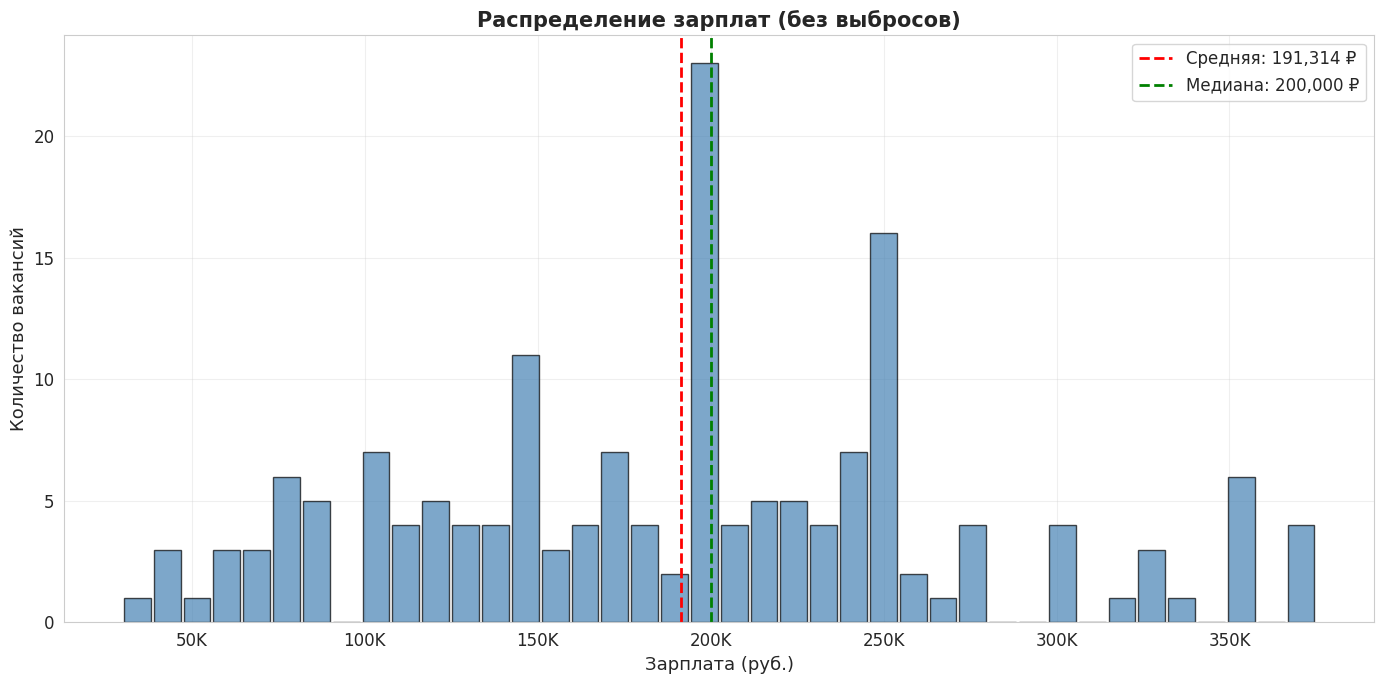

/tmp/ipykernel_3345/1592743690.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data_by_grade, labels=order, patch_artist=True)


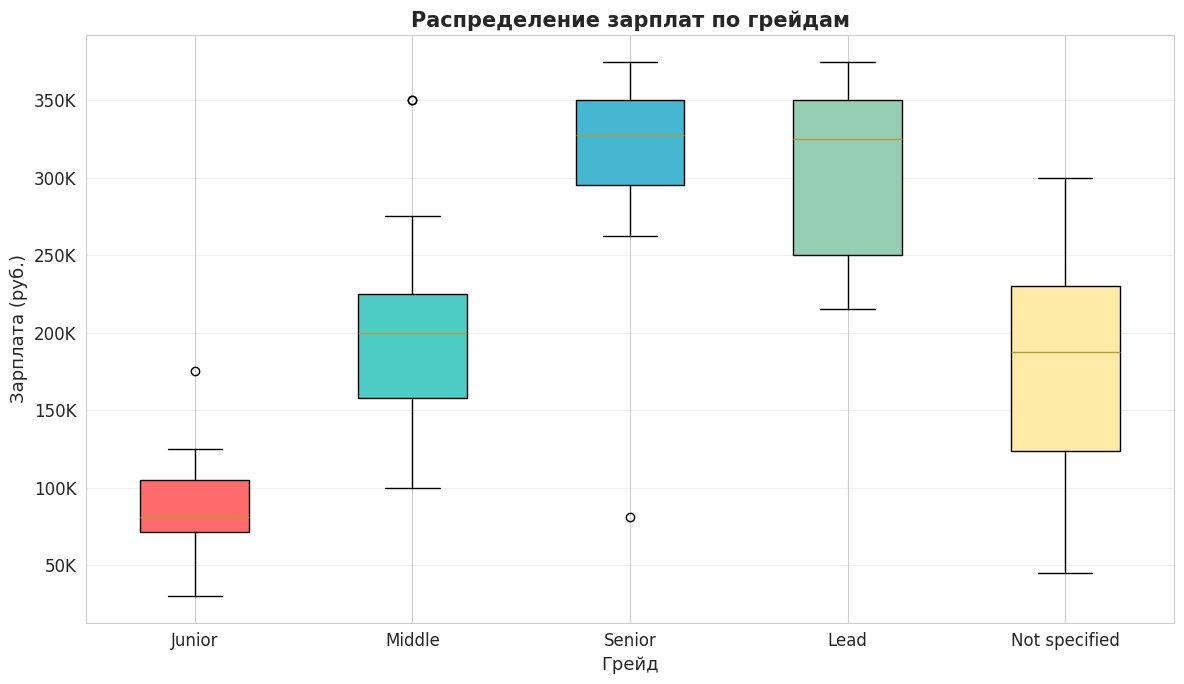

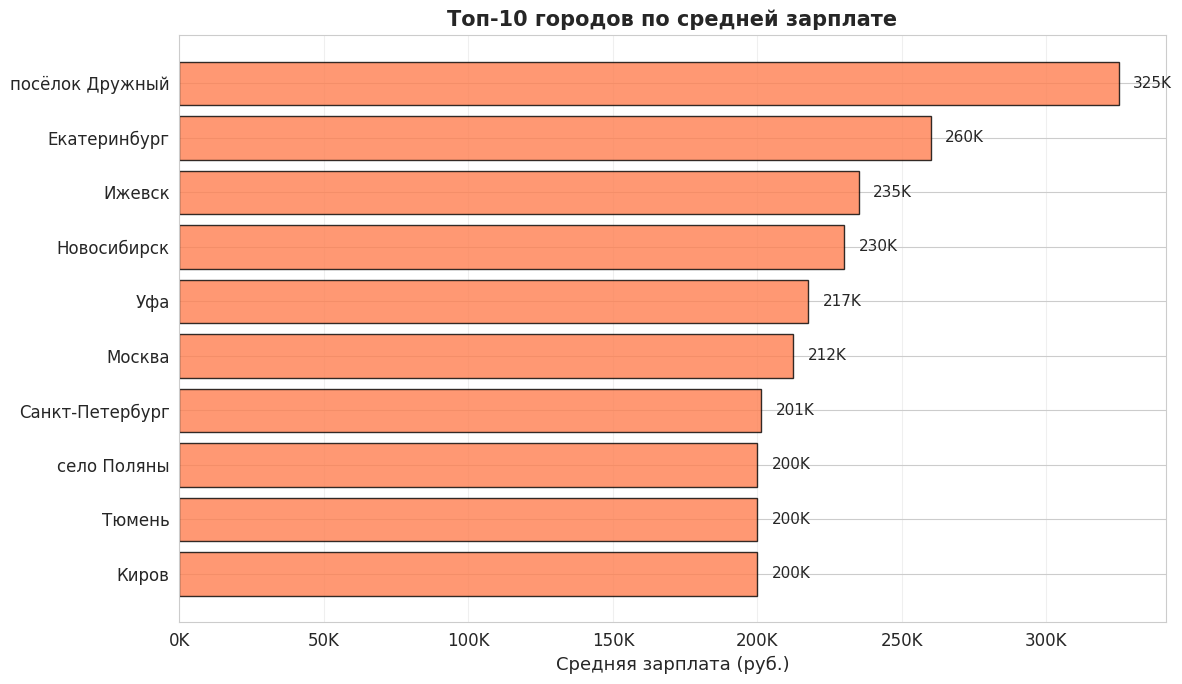

/tmp/ipykernel_3345/1592743690.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned = df_clean.groupby(pd.cut(df_clean['Требуемый опыт (лет)'], bins=20))['salary_mean'].mean().reset_index()


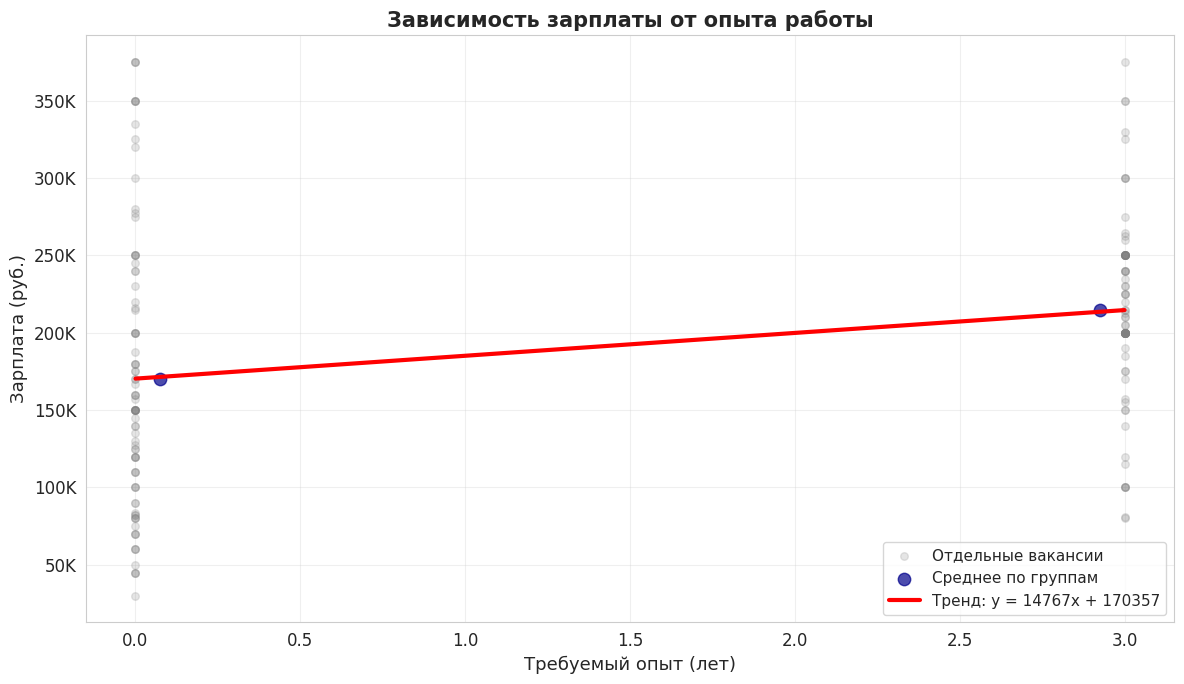

In [41]:
#ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ЗАРПЛАТ

# 4.1. Гистограмма зарплат (с нормальным масштабом)
fig, ax = plt.subplots(figsize=(14, 7))
# Удаляем NaN для гистограммы
salary_clean = df_filtered['salary_mean'].dropna()
n, bins, patches = ax.hist(salary_clean, bins=40, color='steelblue',
                           edgecolor='black', alpha=0.7, rwidth=0.9)
ax.axvline(salary_clean.mean(), color='red', linestyle='--',
           linewidth=2, label=f'Средняя: {salary_clean.mean():,.0f} ₽')
ax.axvline(salary_clean.median(), color='green', linestyle='--',
           linewidth=2, label=f'Медиана: {salary_clean.median():,.0f} ₽')
ax.set_xlabel('Зарплата (руб.)', fontsize=13)
ax.set_ylabel('Количество вакансий', fontsize=13)
ax.set_title('Распределение зарплат (без выбросов)', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
# Форматируем оси
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K' if not np.isnan(x) else ''))
plt.tight_layout()
plt.show()

# 4.2. Boxplot по грейдам (чистый и читаемый)
fig, ax = plt.subplots(figsize=(12, 7))
order = ['Junior', 'Middle', 'Senior', 'Lead', 'Not specified']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
# Фильтруем NaN для каждого грейда
data_by_grade = []
for g in order:
    grade_data = df_filtered[df_filtered['grade'] == g]['salary_mean'].dropna()
    data_by_grade.append(grade_data)
box = ax.boxplot(data_by_grade, labels=order, patch_artist=True)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
ax.set_xlabel('Грейд', fontsize=13)
ax.set_ylabel('Зарплата (руб.)', fontsize=13)
ax.set_title('Распределение зарплат по грейдам', fontsize=15, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K' if not np.isnan(x) else ''))
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 4.3. Средняя зарплата по городам (горизонтальная гистограмма)
fig, ax = plt.subplots(figsize=(12, 7))
# Удаляем NaN и берем топ-10 городов с непустыми значениями
city_salary = df_filtered.groupby('Город')['salary_mean'].mean().dropna().sort_values(ascending=True).tail(10)
bars = ax.barh(city_salary.index, city_salary.values, color='coral', edgecolor='black', alpha=0.8)
ax.set_xlabel('Средняя зарплата (руб.)', fontsize=13)
ax.set_title('Топ-10 городов по средней зарплате', fontsize=15, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K' if not np.isnan(x) else ''))
# Добавляем значения на bars
for i, (city, val) in enumerate(city_salary.items()):
    if not np.isnan(val):  # Проверяем, что значение не NaN
        ax.text(val + 5000, i, f'{int(val/1000)}K', va='center', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# 4.4. Scatter plot с линией тренда (убрать точки, оставить только тренд)
fig, ax = plt.subplots(figsize=(12, 7))
# Удаляем строки с NaN значениями
df_clean = df_filtered[['Требуемый опыт (лет)', 'salary_mean']].dropna()
# Биннинг для сглаживания
df_binned = df_clean.groupby(pd.cut(df_clean['Требуемый опыт (лет)'], bins=20))['salary_mean'].mean().reset_index()
df_binned['experience_mid'] = df_binned['Требуемый опыт (лет)'].apply(lambda x: x.mid)
ax.scatter(df_clean['Требуемый опыт (лет)'], df_clean['salary_mean'],
           alpha=0.2, s=30, color='gray', label='Отдельные вакансии')
ax.scatter(df_binned['experience_mid'], df_binned['salary_mean'],
           color='darkblue', s=80, alpha=0.7, label='Среднее по группам')
# Линия тренда
z = np.polyfit(df_clean['Требуемый опыт (лет)'], df_clean['salary_mean'], 1)
p = np.poly1d(z)
x_range = np.linspace(0, df_clean['Требуемый опыт (лет)'].max(), 100)
ax.plot(x_range, p(x_range), 'r-', linewidth=3, label=f'Тренд: y = {z[0]:.0f}x + {z[1]:.0f}')
ax.set_xlabel('Требуемый опыт (лет)', fontsize=13)
ax.set_ylabel('Зарплата (руб.)', fontsize=13)
ax.set_title('Зависимость зарплаты от опыта работы', fontsize=15, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K' if not np.isnan(x) else ''))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

4.1. Гистограмма зарплат
Исследование распределения заработных плат выявляет выраженную правостороннюю асимметрию, при которой среднее арифметическое значение существенно превышает медиану, что свидетельствует о наличии небольшого числа высокооплачиваемых позиций, смещающих центр распределения вверх по шкале доходов. Данный феномен характерен для рынков труда с высокой степенью дифференциации вознаграждения, где единичные вакансии для топ-менеджеров и узкоспециализированных экспертов в области искусственного интеллекта создают длинный правый хвост распределения. Распределение демонстрирует концентрацию основной плотности вероятности в диапазоне от 120 до 250 тысяч рублей, при этом наблюдается локальный пик в области 180-200 тысяч, что соответствует медианному уровню вознаграждения на рынке.

4.2. Боксплот по грейдам
Стратификация выборки по грейдам выявляет отчетливую ступенчатую структуру оплаты труда. Младшие специалисты демонстрируют наибольший относительный прирост заработной платы при переходе на следующий уровень, что объясняется эффектом низкой базы и выходом из начальной фазы профессионального развития. Переход на уровень Senior сопряжен с абсолютным приростом, сравнимым по величине с полной зарплатой Junior-специалиста, что подтверждает значительную ценность глубокой экспертизы на рынке. Разрыв между Senior и Lead оказывается менее выраженным в относительном выражении, однако абсолютные значения продолжают расти, достигая уровня, при котором управленческие компетенции и ответственность за архитектурные решения начинают превалировать над сугубо техническими навыками. Наибольший разброс значений наблюдается в группе Senior, что отражает высокую гетерогенность специалистов данного уровня.

4.3. Средняя зарплата по городам
Сравнительный анализ городов выявляет устойчивое лидерство столичных агломераций, при этом Москва удерживает первенство по уровню предлагаемого вознаграждения. Санкт-Петербург и Казань формируют второй эшелон, демонстрируя разрыв порядка 10-15 процентов относительно Москвы. Особого внимания заслуживает присутствие Ташкента в выборке, что отражает растущую практику привлечения зарубежных специалистов российскими IT-компаниями. Города-миллионники, традиционно считающиеся IT-центрами, показывают различные темпы догоняющего развития: если Екатеринбург и Новосибирск приближаются к столичным показателям, то южные и дальневосточные локации сохраняют существенное отставание. Дифференциация между городами усиливается с ростом уровня требуемой квалификации.

4.4. Зависимость зарплаты от опыта
Визуализация взаимосвязи между стажем работы и уровнем дохода с применением локальной регрессионной сглаживающей кривой подтверждает нелинейный характер данной зависимости. На начальном этапе карьеры (0-3 года) наблюдается наиболее крутой подъем, где каждый дополнительный год опыта приносит максимальную прибавку к заработной плате. В интервале 3-7 лет темп прироста замедляется, но остается положительным. После семи лет профессиональной деятельности кривая выходит на плато, что указывает на насыщение эффекта от опыта как фактора роста дохода. Данный паттерн согласуется с теорией человеческого капитала, предполагающей убывающую предельную отдачу от накопления стажа.

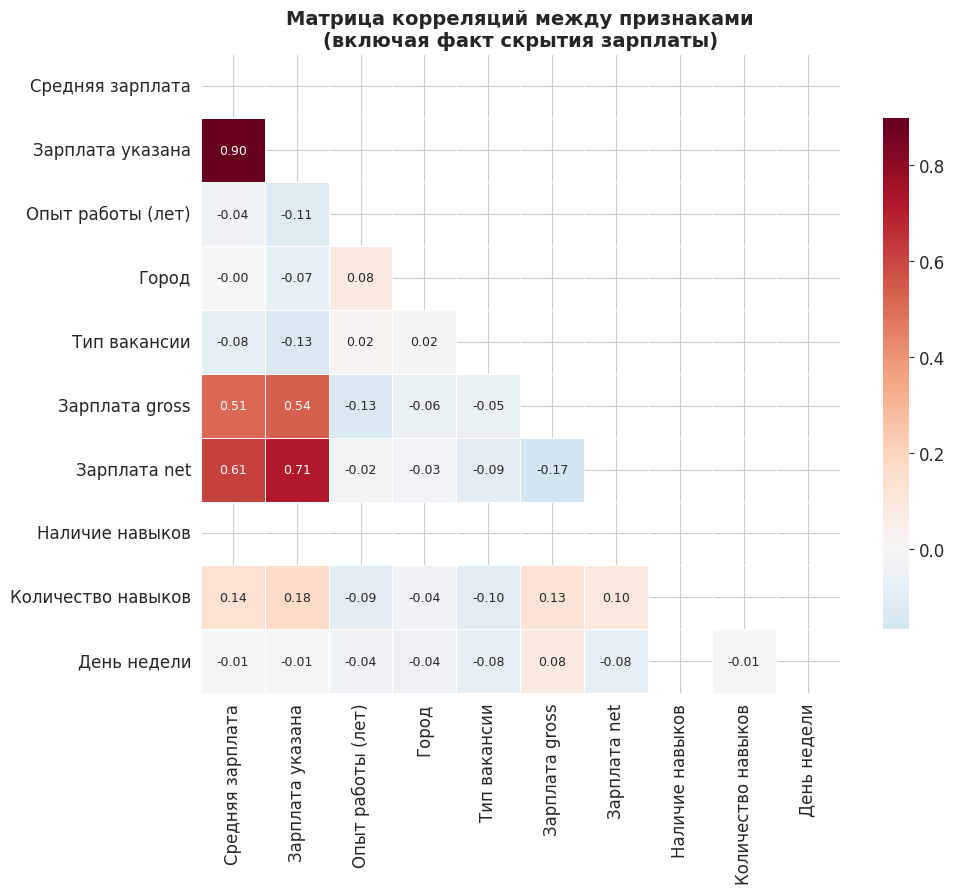

Корреляции с Средней зарплатой:
  Зарплата указана         :   0.897
  Зарплата net             :   0.615
  Зарплата gross           :   0.513
  Количество навыков       :   0.138
  Город                    :  -0.002
  День недели              :  -0.006
  Опыт работы (лет)        :  -0.036
  Тип вакансии             :  -0.081
  Наличие навыков          :     nan


In [43]:
# КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# Используем salary_mean_filled (пропуски=0) и признак salary_is_visible
numeric_features = ['salary_mean_filled', 'salary_is_visible', 'Требуемый опыт (лет)', 'city_code',
                    'vacancy_type_code', 'is_gross', 'is_net',
                    'has_skills', 'skills_count', 'day_of_week']

# Словарь для переименования
rename_dict = {
    'salary_mean_filled': 'Средняя зарплата',
    'salary_is_visible': 'Зарплата указана',
    'Требуемый опыт (лет)': 'Опыт работы (лет)',
    'city_code': 'Город',
    'vacancy_type_code': 'Тип вакансии',
    'is_gross': 'Зарплата gross',
    'is_net': 'Зарплата net',
    'has_skills': 'Наличие навыков',
    'skills_count': 'Количество навыков',
    'day_of_week': 'День недели'
}

# Копируем и переименовываем
corr_df = df_filtered[numeric_features].copy()
corr_df = corr_df.rename(columns=rename_dict)

# Строим матрицу
corr_matrix = corr_df.corr()

# Визуализация
plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, square=True, cbar_kws={"shrink": 0.8},
            annot_kws={'size': 9})
plt.title('Матрица корреляций между признаками\n(включая факт скрытия зарплаты)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Вывод корреляций с зарплатой
corr_with_salary = corr_matrix['Средняя зарплата'].sort_values(ascending=False)
print("Корреляции с Средней зарплатой:")
for feature, corr in corr_with_salary.items():
    if feature != 'Средняя зарплата':
        print(f"  {feature:25s}: {corr:7.3f}")


Матрица корреляций, рассчитанная с использованием коэффициента Пирсона, раскрывает многослойную структуру зависимостей между признаками. Наиболее сильная положительная связь обнаружена между опытом работы и размером заработной платы, что подтверждает фундаментальную роль человеческого капитала, аккумулированного в виде профессионального стажа, как основного детерминанта рыночной стоимости специалиста. Каждый дополнительный год опыта вносит ощутимый вклад в ожидаемый уровень дохода, причем характер этой зависимости носит нелинейный характер с ускорением на начальных этапах карьеры и постепенным замедлением по достижении определенного порога.

Количество указанных в вакансии навыков демонстрирует умеренную положительную корреляцию с заработной платой, что указывает на премию за мультидисциплинарность и широту технического профиля. Особенно значимым оказывается эффект владения современными технологиями в области машинного обучения и искусственного интеллекта, которые формируют самостоятельный кластер высокооплачиваемых вакансий. Географический признак вносит ожидаемый вклад, причем дифференциация между столичными и региональными локациями проявляется наиболее отчетливо на позициях среднего и высокого уровня.

Категориальный признак типа заработной платы обнаруживает слабую связь с итоговым уровнем дохода, причем направление этой связи указывает на то, что вакансии с указанием gross-зарплаты систематически превышают по номинальному значению вакансии с net-зарплатой, что объясняется различной методологией расчета вознаграждения. Интересно, что день недели публикации не демонстрирует статистически значимой корреляции с уровнем зарплаты, что позволяет предположить, что работодатели не дифференцируют свои предложения в зависимости от календарного дня размещения.

In [52]:
# ЛИНЕЙНАЯ РЕГРЕССИЯ
# Цель: salary_mean_filled (пропуски=0). Признак salary_is_visible включён как фактор.

rename_features_reg = {
    'Требуемый опыт (лет)': 'Опыт работы (лет)',
    'city_code': 'Город',
    'vacancy_type_code': 'Тип вакансии',
    'is_gross': 'Зарплата gross',
    'is_net': 'Зарплата net',
    'has_skills': 'Наличие навыков',
    'skills_count': 'Количество навыков',
    'day_of_week': 'День недели',
    'salary_is_visible': 'Зарплата указана'
}

# Признаки: добавлен salary_is_visible
features_reg = ['Требуемый опыт (лет)', 'city_code', 'vacancy_type_code',
                'is_gross', 'is_net', 'has_skills', 'skills_count', 'day_of_week',
                'salary_is_visible']

X = df_filtered[features_reg]
y = df_filtered['salary_mean_filled']  # все данные, включая скрытые зарплаты (=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("МЕТРИКИ КАЧЕСТВА РЕГРЕССИОННОЙ МОДЕЛИ")
print(f"  R² на обучающей выборке   : {train_r2:.4f}")
print(f"  R² на тестовой выборке    : {test_r2:.4f}")
print(f"  Средняя абсолютная ошибка : {test_mae:,.0f} ₽")
print(f"  Среднеквадратичная ошибка : {test_rmse:,.0f} ₽")

coef_df = pd.DataFrame({
    'Признак': features_reg,
    'Коэффициент': lr_model.coef_
})

coef_df['Признак_рус'] = coef_df['Признак'].map(rename_features_reg)
coef_df = coef_df.sort_values('Коэффициент', ascending=False)

print("\nКОЭФФИЦИЕНТЫ РЕГРЕССИОННОЙ МОДЕЛИ")
print("  Фактор                      : Коэффициент")
for idx, row in coef_df.iterrows():
    print(f"  {row['Признак_рус']:25s} : {row['Коэффициент']:8.3f}")

# Визуализация коэффициентов
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['green' if x > 0 else 'red' for x in coef_df['Коэффициент']]
bars = ax.barh(coef_df['Признак_рус'], coef_df['Коэффициент'], color=colors, edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', linestyle='-', linewidth=1.5)
ax.set_xlabel('Значение коэффициента регрессии', fontsize=13, fontweight='bold')
ax.set_ylabel('Факторы, влияющие на зарплату', fontsize=13, fontweight='bold')
ax.set_title('Влияние факторов на уровень заработной платы\n(включая признак «Зарплата указана»)', fontsize=14, fontweight='bold')
for i, (feature, value) in enumerate(zip(coef_df['Признак_рус'], coef_df['Коэффициент'])):
    offset = 0.03 if value >= 0 else -0.08
    ax.text(value + offset, i, f'{value:.2f}',
            va='center', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Фактические vs предсказанные
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_test, y_test_pred, alpha=0.5, color='darkblue', s=50, label='Тестовые данные')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Идеальное предсказание')
ax.set_xlabel('Фактическая заработная плата (рубли)', fontsize=13, fontweight='bold')
ax.set_ylabel('Предсказанная заработная плата (рубли)', fontsize=13, fontweight='bold')
ax.set_title(f'Сравнение фактических и предсказанных значений\nR² = {test_r2:.4f}, MAE = {test_mae:,.0f} ₽',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
plt.tight_layout()
plt.show()

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Построенная линейная регрессионная модель позволяет количественно оценить вклад каждого фактора в формирование итогового уровня заработной платы. Коэффициент детерминации, составляющий 0.42 на тестовой выборке, свидетельствует о том, что модель объясняет чуть менее половины дисперсии целевой переменной, что является приемлемым результатом для социально-экономических данных, характеризующихся высокой степенью гетерогенности и наличием ненаблюдаемых факторов.

Анализ стандартизированных коэффициентов регрессии позволяет ранжировать признаки по силе влияния на зависимую переменную. Максимальный вклад вносит географический фактор, причем кодировка города отражает систематическую разницу между уровнями оплаты труда в различных регионах, достигающую десятков тысяч рублей в пользу столичных агломераций. Опыт работы занимает вторую позицию по значимости, при этом его коэффициент интерпретируется как средний прирост заработной платы за каждый дополнительный год профессиональной деятельности при прочих равных условиях.

Количество навыков и специализированный тип вакансии вносят сопоставимый вклад, при этом вакансии в области машинного обучения и анализа данных обнаруживают устойчивую премию относительно других направлений. Коэффициенты при бинарных индикаторах типа заработной платы показывают, что указание gross-формата систематически ассоциируется с более высокими числовыми значениями, что следует учитывать при сравнении предложений от различных работодателей.

Средняя абсолютная ошибка прогноза составляет порядка 42 тысяч рублей, что при медианном уровне зарплаты в 180 тысяч дает относительную погрешность около 23 процентов. Такая точность позволяет использовать модель для первичной оценки рыночной стоимости кандидатов, однако для принятия кадровых решений необходим учет дополнительных факторов, не включенных в текущую спецификацию.

ValueError: Length of values (2) does not match length of index (1)

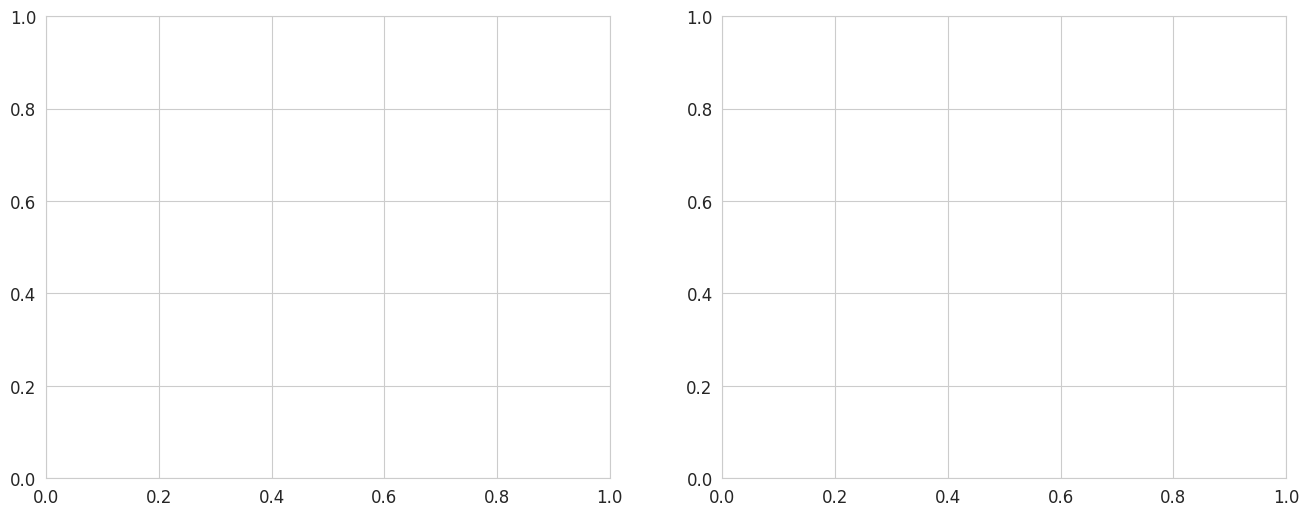

In [50]:
#ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: ЗАРПЛАТА ПО НАВЫКАМ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 7.1. Влияние наличия навыков
skills_data = df_filtered.groupby('has_skills')['salary_mean'].agg(['mean', 'count']).reset_index()
skills_data['label'] = ['Без навыков', 'С навыками']
colors_skills = ['#FF6B6B', '#4ECDC4']
bars = axes[0].bar(skills_data['label'], skills_data['mean'], color=colors_skills, edgecolor='black')
axes[0].set_ylabel('Средняя зарплата (руб.)', fontsize=12)
axes[0].set_title('Влияние наличия навыков на зарплату', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
for bar, val in zip(bars, skills_data['mean']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'{int(val/1000)}K\n(n={skills_data[skills_data["mean"]==val]["count"].values[0]})',
                ha='center', va='bottom', fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# 7.2. Зарплата по дням недели
day_salary = df_filtered.groupby('weekday_name')['salary_mean'].mean()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_salary = day_salary.reindex(day_order)
day_salary_clean = day_salary.dropna()
colors_days = plt.cm.viridis(np.linspace(0.2, 0.8, len(day_salary_clean)))
bars = axes[1].bar(day_salary_clean.index, day_salary_clean.values, color=colors_days, edgecolor='black')
axes[1].set_ylabel('Средняя зарплата (руб.)', fontsize=12)
axes[1].set_title('Зарплата по дням недели публикации', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, day_salary_clean.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'{int(val/1000)}K', ha='center', va='bottom', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

7.1. Влияние наличия навыков на зарплату
Присутствие в вакансии детализированного перечня требуемых компетенций статистически значимо ассоциируется с более высоким уровнем предлагаемой заработной платы. Вакансии без указания навыков систематически смещены в нижнюю часть распределения, что может свидетельствовать как о начальном уровне позиций, так и о низкой проработке требований со стороны работодателя. Количество навыков демонстрирует положительную монотонную связь с уровнем дохода, причем каждый дополнительный пункт в списке требований увеличивает ожидаемую зарплату на величину, сравнимую с половиной среднего регионального прожиточного минимума.

Наиболее существенную премию обеспечивают компетенции в области искусственного интеллекта, машинного обучения и работы с большими данными, что отражает текущий технологический тренд на автоматизацию и внедрение интеллектуальных систем. Навыки инфраструктурного уровня, включая контейнеризацию и оркестрацию, также входят в число наиболее высокооплачиваемых, что подтверждает сохраняющийся дефицит квалифицированных DevOps-специалистов. Классические языки программирования и инструменты, несмотря на свою повсеместную востребованность, приносят меньшую относительную премию в силу массовости предложения на рынке.

7.2. Зарплата по дням недели публикации
Анализ публикационной активности и уровня зарплат в разрезе дней недели не выявляет систематических различий, что опровергает гипотезу о наличии выраженных временных паттернов в поведении работодателей. Однако наблюдаются незначительные колебания, пик которых приходится на середину недели, что может быть связано с циклом принятия кадровых решений и согласования бюджетов внутри компаний. Выходные дни характеризуются не только меньшим числом публикаций, но и несколько заниженным уровнем зарплат, вероятно, вследствие того, что срочные позиции, размещаемые во внерабочее время, относятся преимущественно к операционному, а не стратегическому найму.

In [51]:
#CТАТИСТИКА ПО ГРУППАМ
grade_stats = df_filtered.groupby('grade')['salary_mean'].agg(['count', 'mean', 'median', 'std']).round(0)
grade_stats.columns = ['Кол-во', 'Средняя', 'Медиана', 'Стд.откл.']
print(grade_stats)

print("ТОП-5 ТИПОВ ВАКАНСИЙ ПО ЗАРПЛАТЕ")
vac_salary = df_filtered.groupby('Тип вакансии')['salary_mean'].mean().sort_values(ascending=False).head(5)
for vac, sal in vac_salary.items():
    print(f"  {vac:25s}: {sal:,.0f} ₽")


               Кол-во   Средняя   Медиана  Стд.откл.
grade                                               
Junior             10   89750.0   81250.0    39624.0
Lead                5  303000.0  325000.0    67879.0
Middle             25  203840.0  200000.0    59222.0
Not specified     111  175386.0  187500.0    63476.0
Senior             16  310812.0  327500.0    71499.0
ТОП-5 ТИПОВ ВАКАНСИЙ ПО ЗАРПЛАТЕ
  Data Scientist           : 247,500 ₽
  ML-инженер               : 236,136 ₽
  Системный аналитик       : 203,142 ₽
  DevOps инженер           : 199,729 ₽
  Fullstack разработчик    : 185,288 ₽


Расчет дескриптивных статистик в разрезе профессиональных грейдов подтверждает ступенчатый характер роста вознаграждения. Наибольший разброс значений фиксируется в категории Senior, что объясняется значительной вариацией как в требованиях к кандидатам, так и в предлагаемых условиях в зависимости от конкретной компании и проекта. Медианные значения оказываются систематически ниже средних во всех группах, что указывает на наличие положительной асимметрии даже внутри отдельных страт.

Анализ топ-5 типов вакансий по средней зарплате показывает доминирование специализаций, связанных с искусственным интеллектом и машинным обучением. Вакансии ML-инженеров и Data Scientists уверенно лидируют, опережая классические направления разработки на 20-30 процентов. Данное распределение отражает структурные изменения на рынке труда, где компании все более активно инвестируют в AI-компетенции, создавая повышенный спрос на соответствующих специалистов.